# Introduction

This notebook contains exercises on shrinkage and classification topics covered in the Machine Learning in Finance course.
These tasks are designed to help you practice the concepts introduced in the slides.

* Many problems have multiple valid solutions—feel free to be creative.

* Focus on understanding; don’t be afraid to look up documentation if you get stuck.

* Use the code cells provided to write your answers.

* Solutions are hidden by default—try each exercise yourself first!

# Shrinkage

In this part, we cover two exercises concerning shrinkage topic.

## 1: Shrinkage with Ames Housing Dataset

### Exercise 1.1: Load and Prepare Ames Housing Dataset

* Load the Ames housing dataset using sklearn.datasets.fetch_openml.
* Create a pandas DataFrame containing only numeric columns, and drop rows with missing values.
* Use log(SalePrice) as the target variable.
* Print the shape and first 5 rows of the DataFrame.


In [221]:
# Load the Ames Housing dataset
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np

# Load data from OpenML
data = fetch_openml('house_prices', as_frame=True)
df = data.frame

# Seleting only numeric columns and creating target column
df_1=df.select_dtypes(include="number").dropna()

# Creating x and y 
X=df_1.drop(["SalePrice"],axis=1) 
y=np.log(df_1["SalePrice"])


print(f"Shape of df: {df_1.shape}\n\n{df_1.head(10)}")

Shape of df: (1121, 38)

    Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0    1          60    65.000000     8450            7            5       2003   
1    2          20    80.000000     9600            6            8       1976   
2    3          60    68.000000    11250            7            5       2001   
3    4          70    60.000000     9550            7            5       1915   
4    5          60    84.000000    14260            8            5       2000   
5    6          50    85.000000    14115            5            5       1993   
6    7          20    75.000000    10084            8            5       2004   
8    9          50    51.000000     6120            7            5       1931   
9   10         190    50.000000     7420            5            6       1939   
10  11          20    70.000000    11200            5            5       1965   

    YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  WoodDeckSF  OpenPorchSF  \
0        

### Solution


In [44]:
# Load the Ames Housing dataset
from sklearn.datasets import fetch_openml
import pandas as pd

# Load data from OpenML
data = fetch_openml('house_prices', as_frame=True)
df = data.frame

# Keep only numeric features and drop rows with missing values
df_num = df.select_dtypes(include='number').dropna()

# Define predictors and target
X = df_num.drop('SalePrice', axis=1)
y=np.log(df_num['SalePrice'])

# Print dataset shape and preview
print(f"Shape of numeric, complete-case data: {df_num.shape}")
df_num.head()


# The dataset now contains 1,121 observations and 37 numeric predictors.
# Categorical variables and missing-value rows are dropped. No encoding needed.



Shape of numeric, complete-case data: (1121, 38)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000


### Exercise 1.2: Baseline Linear Regression

* Split the data into training (80%) and test (20%) sets.
* Fit a Linear Regression model to predict log(SalePrice) using all features.
* Compute and print RMSE on the test set.

In [222]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np 


# Creating x and y 
X=df_1.drop(["SalePrice"],axis=1) 
y=np.log(df_1["SalePrice"])

# Simple Train/Test Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,  # sets seed for reproducibility
    shuffle=True      # set to False for time series data
)

#Setting up linear regression 
reg=LinearRegression()

reg.fit(X_train,y_train) #Training set (fit) → learn relationships.
ols_coef=pd.Series(reg.coef_)

y_predicted = reg.predict(X_test) #Test set (predict) → check if the learned relationships generalize to unseen data.


# Metrics for evaluation 
MAE = np.mean(np.abs(y_test- y_predicted))
MSE = np.mean((y_test - y_predicted)**2)
RMSE = np.sqrt(MSE)
MAPE = np.mean(np.abs((y_test-y_predicted) / y)) *100


print(f"MAE: {MAE:.6f}\nRMSE: {RMSE:.6f}\nMSE: {MSE:.6f}\nMAPE {MAPE:.6f} ")


MAE: 0.100068
RMSE: 0.134838
MSE: 0.018181
MAPE 0.825947 


### Solution

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Initialize and fit Linear Regression model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predict on test set
y_pred = linreg.predict(X_test)

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Linear Regression Test RMSE: {rmse:.4f}")

# --- Comments ---
# RMSE is 0.1348.
# The model uses all 37 numeric predictors; scaling isn’t needed for OLS.
# This serves as a baseline to compare with Ridge, Lasso, and Elastic Net models.


Linear Regression Test RMSE: 0.1348


### Exercise 1.3: Ridge Regression

* On training set, fit a Pipeline with StandardScaler and RidgeCV (default settings).
* Predict on the test set and compute RMSE.
* Compare the RidgeCV coefficients with Linear Regression coefficients.
* Which coefficients are shrunk the most? Which are less affected?

In [223]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV

# Simple Train/Test Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,  # sets seed for reproducibility
    shuffle=True      # set to False for time series data
)

# Making the pipe
ridge_pipe = Pipeline([('scaler', StandardScaler()), ('ridge', RidgeCV())])

# --- Ridge regression with CV ---
ridge_pipe.fit(X_train, y_train)
tuned_ridge = ridge_pipe.named_steps['ridge'] # Access the fitted RidgeCV mode
ridge_coef = pd.Series(tuned_ridge.coef_, index=X.columns) # here we get the coef by .coef and make it into a series with X's column as index.

y_predicted_ridge = ridge_pipe.predict(X_test) #Test set (predict) → check if the learned relationships generalize to unseen data.


# Metrics for evaluation 
MAE = np.mean(np.abs(y_test- y_predicted_ridge))
MSE = np.mean((y_test - y_predicted_ridge)**2)
RMSE = np.sqrt(MSE)
MAPE = np.mean(np.abs((y_test-y_predicted_ridge) / y)) *100
print(f"MAE: {MAE:.6f}\nRMSE: {RMSE:.6f}\nMSE: {MSE:.6f}\nMAPE {MAPE:.6f} ")

# --- SCALING RIDGE BACK ----------# 

# 2. Ridge coefficients in original scale we must scale it back. 
scaler = ridge_pipe.named_steps['scaler']

#get ridge coeff on standardized variables
ridge_coefs_scaled = ridge_pipe.named_steps['ridge'].coef_

# Transform back to original scale: divide by scaling factor
ridge_coefs_orig = pd.Series(ridge_coefs_scaled / scaler.scale_)


#=================================
# Printing the results 
#================================
coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'LinearReg': ols_coef,
    'RidgeCV': ridge_coefs_orig
})


# determine the features which shrank the most
coef_comparison['Shrinkage'] = np.abs(coef_comparison['LinearReg']) - np.abs(coef_comparison['RidgeCV'])
shrinkage_sorted = coef_comparison.sort_values('Shrinkage', ascending=False)
print("Sorted after the most shrinked coefficents")
print(shrinkage_sorted[['Feature', 'LinearReg', 'RidgeCV', 'Shrinkage']])

# so for the most shrunken variables: The OLS coefficient for that variable was unstable — small changes in data lead to large swings. Ridge stabilizes these by shrinking them and Ridge prioritizes minimizing overall model variance rather than perfectly fitting every variable’s OLS pattern. Large shrinkage = less critical variable.

print(f"\n\n{coef_comparison}")

MAE: 0.099732
RMSE: 0.134372
MSE: 0.018056
MAPE 0.823112 
Sorted after the most shrinked coefficents
          Feature  LinearReg   RidgeCV  Shrinkage
4     OverallQual   0.093028  0.091008   0.002020
5     OverallCond   0.051531  0.049953   0.001578
26     GarageCars   0.071680  0.070274   0.001406
17   BsmtFullBath   0.069773  0.068563   0.001210
18   BsmtHalfBath   0.020864  0.019864   0.001001
21   BedroomAbvGr  -0.004934 -0.004340   0.000594
36         YrSold  -0.007349 -0.007164   0.000185
6       YearBuilt   0.002508  0.002389   0.000118
35         MoSold  -0.000387 -0.000317   0.000069
16      GrLivArea   0.000123  0.000086   0.000037
1      MSSubClass  -0.000795 -0.000771   0.000024
33       PoolArea  -0.000733 -0.000722   0.000012
30  EnclosedPorch   0.000181  0.000169   0.000011
11      BsmtUnfSF  -0.000013 -0.000003   0.000009
12    TotalBsmtSF   0.000034  0.000028   0.000006
29    OpenPorchSF  -0.000007 -0.000002   0.000005
32    ScreenPorch   0.000391  0.000386   0.000005

### Solution

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

# Create RidgeCV pipeline with default settings
ridge_pipe = Pipeline([('scaler', StandardScaler()),('ridge', RidgeCV())])

# Fit on training data
ridge_pipe.fit(X_train, y_train)

# Predict on test set
y_pred_ridge = ridge_pipe.predict(X_test)

# Compute RMSE
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
print(f"RidgeCV Test RMSE: {rmse_ridge:.4f}")

# --- Compare coefficients ---

# 1. Baseline OLS coefficients
coef_linreg = linreg.coef_

# 2. Ridge coefficients in original scale
#note scale
scaler = ridge_pipe.named_steps['scaler']
#get ridge coeff on standardized variables
ridge_coefs_scaled = ridge_pipe.named_steps['ridge'].coef_

# Transform back to original scale: divide by scaling factor
ridge_coefs_orig = ridge_coefs_scaled / scaler.scale_

# 3. Combine into a DataFrame
coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'LinearReg': coef_linreg,
    'RidgeCV': ridge_coefs_orig
})

print("\nCoefficient comparison (original feature scale):")
print(coef_comparison)

# --- Comments ---
#  RidgeCV Test RMSE: 0.1344 — slightly better than OLS.
#   On log scale, this corresponds to typical prediction errors of ~13–14%.
#
# Coefficients are gently shrunk toward zero; the largest reductions are seen
#  in predictors with higher magnitude (e.g., 'OverallQual', 'GrLivArea', 'BsmtFullBath').
#   No coefficients are exactly zero — Ridge stabilizes estimates without feature elimination.


RidgeCV Test RMSE: 0.1344

Coefficient comparison (original feature scale):
          Feature  LinearReg   RidgeCV
0              Id  -0.000008 -0.000008
1      MSSubClass  -0.000795 -0.000771
2     LotFrontage   0.000158  0.000179
3         LotArea   0.000001  0.000001
4     OverallQual   0.093028  0.091008
5     OverallCond   0.051531  0.049953
6       YearBuilt   0.002508  0.002389
7    YearRemodAdd   0.000857  0.000958
8      MasVnrArea  -0.000010 -0.000006
9      BsmtFinSF1   0.000014  0.000024
10     BsmtFinSF2   0.000033  0.000042
11      BsmtUnfSF  -0.000013 -0.000003
12    TotalBsmtSF   0.000034  0.000028
13       1stFlrSF   0.000055  0.000087
14       2ndFlrSF   0.000021  0.000054
15   LowQualFinSF   0.000047  0.000076
16      GrLivArea   0.000123  0.000086
17   BsmtFullBath   0.069773  0.068563
18   BsmtHalfBath   0.020864  0.019864
19       FullBath   0.064353  0.065258
20       HalfBath   0.035166  0.036047
21   BedroomAbvGr  -0.004934 -0.004340
22   KitchenAbvGr  -0.09184

### Exercise 1.4: Lasso Regression

* On the training set, fit a Pipeline with StandardScaler and LassoCV (default settings).
* Predict on the test set and compute RMSE.
* Compare the Lasso coefficients with Linear Regression coefficients.
* Which coefficients are shrunk the most? which coefficients are set to zero?

In [224]:
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
pd.set_option('display.float_format', '{:.6f}'.format) #show 6 decimals in coeffs

# ====================================
# Simple Train/Test Split (80% / 20%)
# ====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,  # sets seed for reproducibility
    shuffle=True      # set to False for time series data
)
# Making the pipe
lasso_pipe = Pipeline([('scaler', StandardScaler()), ('lasso', LassoCV())])

# fitting and Predicing and computing RMSE
lasso_pipe.fit(X_train,y_train)

y_predicted_lasso = lasso_pipe.predict(X_test)

# ====================================
# Creating metrics 
# ====================================
best_alpha = lasso_pipe.named_steps['lasso'].alpha_

MSE = np.mean((y_test - y_predicted_lasso)**2)

RMSE = np.sqrt(MSE)


print(f"RMSE: {RMSE:.5f}")
print(f"Selected alpha (default settings): {best_alpha:.4f}")

# ====================================
# SCALING Lasso coeficient BACK 
# ====================================
 
scaler = lasso_pipe.named_steps['scaler']

#get lasso coeff on standardized variables
lasso_coefs_scaled = lasso_pipe.named_steps['lasso'].coef_

# Transform back to original scale: divide by scaling factor
lasso_coefs_orig = pd.Series(lasso_coefs_scaled / scaler.scale_)

# ====================================
# Printing the results 
# ====================================
coef_comparison_lasso = pd.DataFrame({
    'Feature': X.columns,
    'LinearReg': ols_coef,
    'LassoCV': lasso_coefs_orig
})
print(f"\n\n{coef_comparison_lasso}")

# ========================================================================
# determine the features which shrank the most
# ========================================================================
coef_comparison_lasso['Shrinkage'] = np.abs(coef_comparison_lasso['LinearReg']) - np.abs(coef_comparison_lasso['LassoCV'])
shrinkage_sorted_lasso = coef_comparison_lasso.sort_values('Shrinkage', ascending=False)

print("\nTop 8 most shrunk coefficents:\n", shrinkage_sorted_lasso.head(8)) # shows top 8 adjust it 
print("\nFeatures with most shrinkage:\n", shrinkage_sorted["Feature"].head(8)) # prints the variables must shrunk

#=========== COMMENT FOR THE MOST SHRANK COEFFICIENT ==============# 
# so for the most shrunken variables: The OLS coefficient for that variable was unstable — small changes in data lead to large swings. Ridge stabilizes these by shrinking them and Ridge prioritizes minimizing overall model variance rather than perfectly fitting every variable’s OLS pattern. Large shrinkage = less critical variable.



# ========================================================================
# The features that was set = 0 due to lasso' variable selection # 
# ========================================================================

# Create a boolean mask for coefficients=0
mask = coef_comparison_lasso["LassoCV"] == 0

# Print only rows where YearBuilt >= 2010
print("\nThe following variables was dropped by Lasso due to variable selection feature:\n", coef_comparison_lasso[mask])









RMSE: 0.13304
Selected alpha (default settings): 0.0033


          Feature  LinearReg   LassoCV
0              Id  -0.000008 -0.000001
1      MSSubClass  -0.000795 -0.000726
2     LotFrontage   0.000158  0.000116
3         LotArea   0.000001  0.000001
4     OverallQual   0.093028  0.096077
5     OverallCond   0.051531  0.045114
6       YearBuilt   0.002508  0.002279
7    YearRemodAdd   0.000857  0.001057
8      MasVnrArea  -0.000010  0.000000
9      BsmtFinSF1   0.000014  0.000024
10     BsmtFinSF2   0.000033  0.000030
11      BsmtUnfSF  -0.000013 -0.000000
12    TotalBsmtSF   0.000034  0.000021
13       1stFlrSF   0.000055  0.000029
14       2ndFlrSF   0.000021  0.000000
15   LowQualFinSF   0.000047  0.000000
16      GrLivArea   0.000123  0.000150
17   BsmtFullBath   0.069773  0.063184
18   BsmtHalfBath   0.020864  0.007095
19       FullBath   0.064353  0.052908
20       HalfBath   0.035166  0.025825
21   BedroomAbvGr  -0.004934  0.000000
22   KitchenAbvGr  -0.091840 -0.081653
23   T

### Solution

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
pd.set_option('display.float_format', '{:.6f}'.format) #show 6 decimals in coeffs

# Create LassoCV pipeline (default settings)
lasso_pipe = Pipeline([('scaler', StandardScaler()),('lasso', LassoCV())])

# Fit on training data
lasso_pipe.fit(X_train, y_train)

# Predict on test set
y_pred_lasso = lasso_pipe.predict(X_test)

# Compute RMSE
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
best_alpha = lasso_pipe.named_steps['lasso'].alpha_

print(f"Selected alpha (default settings): {best_alpha:.4f}")
print(f"LassoCV Test RMSE: {rmse_lasso:.4f}")

# --- Compare coefficients ---

# Baseline OLS coefficients
coef_linreg = linreg.coef_

# Lasso coefficients are trained on standardized features; transform back to original scale
scaler = lasso_pipe.named_steps['scaler']
lasso_coefs_scaled = lasso_pipe.named_steps['lasso'].coef_
lasso_coefs_orig = lasso_coefs_scaled / scaler.scale_

# Combine into a DataFrame
coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'LinearReg': coef_linreg,
    'LassoCV': lasso_coefs_orig
})

print("\nCoefficient comparison (original feature scale):")
print(coef_comparison)

# --- Comments ---
# Lasso Test RMSE: 0.1330 — slightly better than OLS (0.1348) and Ridge (0.1344).
#
# Variables shrunk to exactly zero (implicit feature selection) include:
# 'MasVnrArea', '2ndFlrSF', 'LowQualFinSF', 'BedroomAbvGr',
#'OpenPorchSF', 'MiscVal', 'MoSold'.
#
# Non-zero coefficients are modestly reduced relative to OLS, especially:
# 'KitchenAbvGr', 'FullBath', 'HalfBath', 'BsmtHalfBath',
# 'GrLivArea', 'BsmtFullBath', 'OverallCond'.






Selected alpha (default settings): 0.0033
LassoCV Test RMSE: 0.1330

Coefficient comparison (original feature scale):
          Feature  LinearReg   LassoCV
0              Id  -0.000008 -0.000001
1      MSSubClass  -0.000795 -0.000726
2     LotFrontage   0.000158  0.000116
3         LotArea   0.000001  0.000001
4     OverallQual   0.093028  0.096077
5     OverallCond   0.051531  0.045114
6       YearBuilt   0.002508  0.002279
7    YearRemodAdd   0.000857  0.001057
8      MasVnrArea  -0.000010  0.000000
9      BsmtFinSF1   0.000014  0.000024
10     BsmtFinSF2   0.000033  0.000030
11      BsmtUnfSF  -0.000013 -0.000000
12    TotalBsmtSF   0.000034  0.000021
13       1stFlrSF   0.000055  0.000029
14       2ndFlrSF   0.000021  0.000000
15   LowQualFinSF   0.000047  0.000000
16      GrLivArea   0.000123  0.000150
17   BsmtFullBath   0.069773  0.063184
18   BsmtHalfBath   0.020864  0.007095
19       FullBath   0.064353  0.052908
20       HalfBath   0.035166  0.025825
21   BedroomAbvGr  -0.00

### Exercise 1.5: Elastic Net Regression 

* On the training set, fit a Pipeline with StandardScaler and ElasticNetCV (default settings).
* Predict on the test set and compute RMSE.
* Compare the ElasticNet coefficients with Linear Regression coefficients.
* Which coefficients are shrunk the most? Which are less affected?

In [80]:
from sklearn.linear_model import ElasticNetCV
pd.set_option('display.float_format', '{:.6f}'.format) #show 6 decimals in coeffs
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline




# ====================================
# Simple Train/Test Split (80% / 20%)
# ====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,  # sets seed for reproducibility
    shuffle=True      # set to False for time series data
)
# Making the pipe
elasticnet_pipe = Pipeline([('scaler', StandardScaler()), ('elastic', ElasticNetCV())]) # Defatilt is l1_ratio= 0.5 and CV= 5 

# fitting and Predicing and computing RMSE
elasticnet_pipe.fit(X_train,y_train)

y_predicted_elastic = elasticnet_pipe.predict(X_test)

# ====================================
# Creating metrics 
# ====================================
best_alpha = elasticnet_pipe.named_steps['elastic'].alpha_

best_l1_ratio = elasticnet_pipe.named_steps['elastic'].l1_ratio_

MSE = np.mean((y_test - y_predicted_elastic)**2)
RMSE = np.sqrt(MSE)


print(f"RMSE: {RMSE:.4f}")
print(f"Selected alpha (default settings): {best_alpha:.4f}")
print(f"Selected l1_ratio (default settings): {best_l1_ratio:.4f}")

# ====================================
# SCALING Lasso coeficient BACK 
# ====================================
 
scaler = elasticnet_pipe.named_steps['scaler']

#get lasso coeff on standardized variables
elastic_coefs_scaled = elasticnet_pipe.named_steps['elastic'].coef_

# Transform back to original scale: divide by scaling factor
elastic_coefs_orig = pd.Series(elastic_coefs_scaled / scaler.scale_)

# ====================================
# Printing the results 
# ====================================
coef_comparison_elastic = pd.DataFrame({
    'Feature': X.columns,
    'LinearReg': ols_coef,
    'ElasticCV': elastic_coefs_orig
})
print(f"\n\n{coef_comparison_elastic}")

# ========================================================================
# determine the features which shrank the most
# ========================================================================
coef_comparison_elastic['Shrinkage'] = np.abs(coef_comparison_elastic['LinearReg']) - np.abs(coef_comparison_elastic['ElasticCV'])
shrinkage_sorted_elastic = coef_comparison_elastic.sort_values('Shrinkage', ascending=False)

print("\nTop 8 most shrunk coefficents:\n", shrinkage_sorted_elastic.head(8)) # shows top 8 adjust it 
print("\nFeatures with most shrinkage:\n", shrinkage_sorted_elastic["Feature"].head(8)) # prints the variables must shrunk

#=========== COMMENT FOR THE MOST SHRANK COEFFICIENT ==============# 
# so for the most shrunken variables: The OLS coefficient for that variable was unstable — small changes in data lead to large swings. Ridge stabilizes these by shrinking them and Ridge prioritizes minimizing overall model variance rather than perfectly fitting every variable’s OLS pattern. Large shrinkage = less critical variable.



# ========================================================================
# The features that was set = 0 due to lasso' variable selection # 
# ========================================================================

# Create a boolean mask for coefficients=0
mask = coef_comparison_elastic["ElasticCV"] == 0

# Print only rows where YearBuilt >= 2010
print("\nThe following variables was dropped by elasticnet due to variable selection feature:\n", coef_comparison_elastic[mask])












RMSE: 0.1330
Selected alpha (default settings): 0.0067
Selected l1_ratio (default settings): 0.5000


          Feature  LinearReg  ElasticCV
0              Id  -0.000008  -0.000001
1      MSSubClass  -0.000795  -0.000716
2     LotFrontage   0.000158   0.000124
3         LotArea   0.000001   0.000001
4     OverallQual   0.093028   0.095474
5     OverallCond   0.051531   0.044710
6       YearBuilt   0.002508   0.002242
7    YearRemodAdd   0.000857   0.001082
8      MasVnrArea  -0.000010   0.000000
9      BsmtFinSF1   0.000014   0.000024
10     BsmtFinSF2   0.000033   0.000030
11      BsmtUnfSF  -0.000013  -0.000000
12    TotalBsmtSF   0.000034   0.000022
13       1stFlrSF   0.000055   0.000031
14       2ndFlrSF   0.000021   0.000000
15   LowQualFinSF   0.000047   0.000000
16      GrLivArea   0.000123   0.000147
17   BsmtFullBath   0.069773   0.062852
18   BsmtHalfBath   0.020864   0.006769
19       FullBath   0.064353   0.053854
20       HalfBath   0.035166   0.026872
21   BedroomAbvGr 

### Solution

In [ ]:
from sklearn.linear_model import ElasticNetCV

# Create ElasticNetCV pipeline (default settings)
elastic_pipe = Pipeline([('scaler', StandardScaler()),('elastic', ElasticNetCV())])

# Fit on training data
elastic_pipe.fit(X_train, y_train)

# Predict on test set
y_pred_elastic = elastic_pipe.predict(X_test)

# Compute RMSE
rmse_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
best_alpha = elastic_pipe.named_steps['elastic'].alpha_
best_l1_ratio = elastic_pipe.named_steps['elastic'].l1_ratio_

print(f"Selected alpha (default settings): {best_alpha:.4f}")
print(f"Selected l1_ratio (default settings): {best_l1_ratio:.4f}")
print(f"ElasticNetCV Test RMSE: {rmse_elastic:.4f}")

# --- Compare coefficients ---

# Baseline OLS coefficients
coef_linreg = linreg.coef_

# ElasticNet coefficients are trained on standardized features; transform back
scaler = elastic_pipe.named_steps['scaler']
elastic_coefs_scaled = elastic_pipe.named_steps['elastic'].coef_
elastic_coefs_orig = elastic_coefs_scaled / scaler.scale_

# Combine into a DataFrame
coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'LinearReg': coef_linreg,
    'ElasticNet': elastic_coefs_orig
})

print("\nCoefficient comparison (original feature scale):")
print(coef_comparison)

# --- Comments ---
# ElasticNetCV Test RMSE: 0.1330 — slightly better than OLS (0.1348) and Ridge (0.1344) matching LassoCV.
#
#Variables shrunk to exactly zero include: 'MasVnrArea', '2ndFlrSF', 'LowQualFinSF',
#'BedroomAbvGr', 'OpenPorchSF', 'MiscVal', 'MoSold', similar to Lasso.
#
#Non-zero coefficients are modestly reduced relative to OLS, especially:
#'KitchenAbvGr', 'FullBath', 'HalfBath', 'BsmtHalfBath', 'GrLivArea',
#'BsmtFullBath', 'OverallCond'. ElasticNet smooths shrinkage across correlated predictors.





Selected alpha (default settings): 0.0067
Selected l1_ratio (default settings): 0.5000
ElasticNetCV Test RMSE: 0.1330

Coefficient comparison (original feature scale):
          Feature  LinearReg  ElasticNet
0              Id  -0.000008   -0.000001
1      MSSubClass  -0.000795   -0.000716
2     LotFrontage   0.000158    0.000124
3         LotArea   0.000001    0.000001
4     OverallQual   0.093028    0.095474
5     OverallCond   0.051531    0.044710
6       YearBuilt   0.002508    0.002242
7    YearRemodAdd   0.000857    0.001082
8      MasVnrArea  -0.000010    0.000000
9      BsmtFinSF1   0.000014    0.000024
10     BsmtFinSF2   0.000033    0.000030
11      BsmtUnfSF  -0.000013   -0.000000
12    TotalBsmtSF   0.000034    0.000022
13       1stFlrSF   0.000055    0.000031
14       2ndFlrSF   0.000021    0.000000
15   LowQualFinSF   0.000047    0.000000
16      GrLivArea   0.000123    0.000147
17   BsmtFullBath   0.069773    0.062852
18   BsmtHalfBath   0.020864    0.006769
19       Ful

### Exercise 1.6: Challenge —Elastic Net Model Selection via Cross-Validation

* On the training set, fit a Pipeline with StandardScaler and ElasticNetCV using the following settings:
  * a grid of 100 penalty parameters logarithmically spaced between $10^{-3}$ and $10^1$,
  * a grid of 5 weight parameters [0.1, 0.3, 0.5, 0.7, 0.9],
  * 5-fold cross validation.
* Predict on the test set and compute RMSE.
* Compare RMSE and coefficients, and discuss which method performs best.
* Compare coefficients with baseline LinearRegression coefficients.
* Which variables are most affected by shrinkage?



In [85]:
from sklearn.linear_model import ElasticNetCV
pd.set_option('display.float_format', '{:.6f}'.format) #show 6 decimals in coeffs
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline




# ====================================
# Simple Train/Test Split (80% / 20%)
# ====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,  # sets seed for reproducibility
    shuffle=True      # set to False for time series data
)
# Making the pipe
elasticnet_pipe = Pipeline(
    [('scaler', StandardScaler()),
    ('elastic', ElasticNetCV(
        l1_ratio=[0.1,0.3,0.5,0.7,0.9],
        cv=5, 
        alphas=np.logspace(-3,1,100,base=10)))]) 

#---------------------------- Adjustments for the elasticnet---------------------#

# log space explained: # np.logspace(start, stop, num=50, base=10.0), Example:
#   np.logspace(-4, 2, 7)
#   → array([# 10^-4, 10^-3, 10^-2, 10^-1, 10^0, 10^1, 10^2])

# alpha	How strongly we penalize large coefficients	Volume knob (how much regularization) Larger → stronger shrinkage
# l1_ratio	How the penalty is split between L1 and L2	Balance knob (Lasso vs Ridge) 0 → Ridge, 1 → Lasso

# -------------------------------------------------------------------------------#

# fitting and Predicing and computing RMSE
elasticnet_pipe.fit(X_train,y_train)

y_predicted_elastic = elasticnet_pipe.predict(X_test)

# ====================================
# Creating metrics 
# ====================================
best_alpha = elasticnet_pipe.named_steps['elastic'].alpha_

best_l1_ratio = elasticnet_pipe.named_steps['elastic'].l1_ratio_

MSE = np.mean((y_test - y_predicted_elastic)**2)
RMSE = np.sqrt(MSE)


print(f"RMSE: {RMSE:.4f}")
print(f"Selected alpha : {best_alpha:.4f}")
print(f"Selected l1_ratio : {best_l1_ratio:.4f}")

# ====================================
# SCALING elastic coeficient BACK 
# ====================================
 
scaler = elasticnet_pipe.named_steps['scaler']

#get lasso coeff on standardized variables
elastic_coefs_scaled = elasticnet_pipe.named_steps['elastic'].coef_

# Transform back to original scale: divide by scaling factor
elastic_coefs_orig = pd.Series(elastic_coefs_scaled / scaler.scale_)

# ====================================
# Printing the results 
# ====================================
coef_comparison_elastic = pd.DataFrame({
    'Feature': X.columns,
    'LinearReg': ols_coef,
    'ElasticCV': elastic_coefs_orig
})
print(f"\n\n{coef_comparison_elastic}")

# ========================================================================
# determine the features which shrank the most
# ========================================================================
coef_comparison_elastic['Shrinkage'] = np.abs(coef_comparison_elastic['LinearReg']) - np.abs(coef_comparison_elastic['ElasticCV'])
shrinkage_sorted_elastic = coef_comparison_elastic.sort_values('Shrinkage', ascending=False)

print("\nTop 8 most shrunk coefficents:\n", shrinkage_sorted_elastic.head(8)) # shows top 8 adjust it 
print("\nFeatures with most shrinkage:\n", shrinkage_sorted_elastic["Feature"].head(8)) # prints the variables must shrunk

#=========== COMMENT FOR THE MOST SHRANK COEFFICIENT ==============# 
# so for the most shrunken variables: The OLS coefficient for that variable was unstable — small changes in data lead to large swings. Ridge stabilizes these by shrinking them and Ridge prioritizes minimizing overall model variance rather than perfectly fitting every variable’s OLS pattern. Large shrinkage = less critical variable.



# ========================================================================
# The features that was set = 0 due to lasso' variable selection # 
# ========================================================================

# Create a boolean mask for coefficients=0
mask = coef_comparison_elastic["ElasticCV"] == 0

# Print only rows where YearBuilt >= 2010
print("\nThe following variables was dropped by elasticnet due to variable selection feature:\n", coef_comparison_elastic[mask])












RMSE: 0.1327
Selected alpha : 0.0343
Selected l1_ratio : 0.1000


          Feature  LinearReg  ElasticCV
0              Id  -0.000008  -0.000002
1      MSSubClass  -0.000795  -0.000642
2     LotFrontage   0.000158   0.000178
3         LotArea   0.000001   0.000001
4     OverallQual   0.093028   0.090819
5     OverallCond   0.051531   0.041701
6       YearBuilt   0.002508   0.002003
7    YearRemodAdd   0.000857   0.001256
8      MasVnrArea  -0.000010   0.000000
9      BsmtFinSF1   0.000014   0.000025
10     BsmtFinSF2   0.000033   0.000027
11      BsmtUnfSF  -0.000013  -0.000000
12    TotalBsmtSF   0.000034   0.000028
13       1stFlrSF   0.000055   0.000038
14       2ndFlrSF   0.000021   0.000000
15   LowQualFinSF   0.000047   0.000000
16      GrLivArea   0.000123   0.000128
17   BsmtFullBath   0.069773   0.060110
18   BsmtHalfBath   0.020864   0.004083
19       FullBath   0.064353   0.058991
20       HalfBath   0.035166   0.032653
21   BedroomAbvGr  -0.004934   0.000000
22   KitchenAb

### Solution

In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Build pipeline
enet_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('enet', ElasticNetCV(
        alphas=np.logspace(-3, 1, 100),     # λ grid: 100 log-spaced values from 1e-3 to 10
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], # α grid: 5 mixing weights
        cv=5,))])

# Fit on training data
enet_pipe.fit(X_train, y_train)

# Retrieve best λ (alpha) and α (l1_ratio)
best_lambda = enet_pipe.named_steps['enet'].alpha_
best_l1_ratio = enet_pipe.named_steps['enet'].l1_ratio_
print(f"Best λ (alpha): {best_lambda:.6f}")
print(f"Best α (l1_ratio): {best_l1_ratio:.2f}")

# Predict and compute RMSE on test set
y_pred_enet = enet_pipe.predict(X_test)
rmse_enet = np.sqrt(mean_squared_error(y_test, y_pred_enet))
print(f"ElasticNetCV Test RMSE: {rmse_enet:.4f}")

# Compare coefficients to OLS (rescaled to original feature units)
enet_coefs_scaled = enet_pipe.named_steps['enet'].coef_
scaler = enet_pipe.named_steps['scaler']
enet_coefs_orig = enet_coefs_scaled / scaler.scale_

coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'LinearReg': linreg.coef_,
    'ElasticNetCV': enet_coefs_orig
})

print("\nCoefficient comparison (original feature scale):")
print(coef_comparison)

# --- Comments ---
# Test RMSE: 0.1327 — the lowest among all previous models, showing that careful cross-validation
# with a broad grid of penalty (alpha) and mixing (l1_ratio) parameters improved predictive performance.
#
# Coefficient shrinkage:
# Strongest predictors (OverallQual, GrLivArea, FullBath) remain largely intact.
# Weaker or redundant variables (BedroomAbvGr, LowQualFinSF, OpenPorchSF, MoSold) are shrunk to
# zero or near-zero, illustrating effective sparsity.
#
# Best parameters:
# alpha ≈ 0.0343, l1_ratio = 0.10 — mostly Ridge-like regularization with mild L1 contribution.







Best λ (alpha): 0.034305
Best α (l1_ratio): 0.10
ElasticNetCV Test RMSE: 0.1327

Coefficient comparison (original feature scale):
          Feature  LinearReg  ElasticNetCV
0              Id  -0.000008     -0.000002
1      MSSubClass  -0.000795     -0.000642
2     LotFrontage   0.000158      0.000178
3         LotArea   0.000001      0.000001
4     OverallQual   0.093028      0.090819
5     OverallCond   0.051531      0.041701
6       YearBuilt   0.002508      0.002003
7    YearRemodAdd   0.000857      0.001256
8      MasVnrArea  -0.000010      0.000000
9      BsmtFinSF1   0.000014      0.000025
10     BsmtFinSF2   0.000033      0.000027
11      BsmtUnfSF  -0.000013     -0.000000
12    TotalBsmtSF   0.000034      0.000028
13       1stFlrSF   0.000055      0.000038
14       2ndFlrSF   0.000021      0.000000
15   LowQualFinSF   0.000047      0.000000
16      GrLivArea   0.000123      0.000128
17   BsmtFullBath   0.069773      0.060110
18   BsmtHalfBath   0.020864      0.004083
19       F

## 2: Shrinkage with Simulated Dataset

We will use the simulated dataset created earlier.
The dataset contains $n=200$ observations and $p=50$ predictors, where only the first 10 truly affect the outcome $y.$ Please run the code cell below before starting these exercises.

As with the previous slides, remember to use a copy of the df when making alterations, so you can reuse it for other exercises. Alternatively load the dataset indenpendtly for each exercise.

In [87]:
import numpy as np
import pandas as pd

# Reproducibility
np.random.seed(42)

# Parameters
n = 200      # number of observations
p = 50       # total predictors
true_p = 10  # number of true non-zero coefficients

# Fixed non-zero coefficients for first true_p predictors
beta = np.zeros(p)
beta[:true_p] = [5, 4, 3, 2.5, 2, 1.5, 1, 0.8, 0.5, 0.3]

# Simulate predictors with different scales to make StandardScaler meaningful
X = np.random.normal(size=(n, p)) * np.linspace(2, 5, p)
# Features have increasing sclaing: X1-2, X2-2.06, ..., X50-5.


# Generate response with Gaussian noise
y = X @ beta + np.random.normal(0, 1, n)

# Create DataFrame
columns = [f"X{i+1}" for i in range(p)]
df_1 = pd.DataFrame(X, columns=columns)
df_1['y'] = y


df_1.to_csv('shrinkage_sample.csv', index=False)
print("Sample dataset saved as 'shrinkage_sample.csv'.")
print(df_1.head())


Sample dataset saved as 'shrinkage_sample.csv'.
         X1        X2        X3        X4        X5        X6        X7  \
0  0.993428 -0.284994  1.374686  3.325800 -0.525650 -0.539948  3.738545   
1  0.648168 -0.793741 -1.436732  1.335701  2.314489  2.147646 -1.986719   
2 -2.830741 -0.867044 -0.727394 -1.751912 -0.362070  0.931791  4.465256   
3  0.500986  0.714108 -1.443318  0.507166  0.657918 -1.647382  4.416936   
4  0.715575  1.155903  2.298721  2.301160 -3.092727 -2.162739  1.219267   

         X8        X9       X10  ...       X42       X43       X44       X45  \
0  1.863770 -1.168895  1.384082  ...  0.772906 -0.528678 -1.394909 -6.940001   
1 -0.750944  0.824778  2.488636  ...  4.368787 -3.209386 -1.517945 -1.840508   
2  0.423975  0.641248 -0.189913  ...  5.895481 -7.348495  0.855345  1.219858   
3  1.150737 -2.966103  1.674882  ...  3.862533  0.978714 -5.771076  0.812890   
4  1.247766  1.282364  9.828397  ... -0.517485  2.308513  4.010743 -5.634044   

        X46       X4

### Exercise 2.1: Linear Regression Baseline

* Fit an OLS regression on the training set (70%)
* Predict on the test set (30%) and compute RMSE.
* Display and inspect coefficients.
* Compare estimated coefficients with the true β values.
* Comment on which predictors have the largest estimated impact.

In [106]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np 


# Simple Train/Test Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,  # sets seed for reproducibility
    shuffle=True      # set to False for time series data
)

#Setting up linear regression 
reg=LinearRegression()
reg.fit(X_train,y_train) #Training set (fit) → learn relationships.

# Savining coefficient and predicting y from x-test.
ols_coef=pd.Series(reg.coef_)

y_predicted_ols = reg.predict(X_test) #Test set (predict) → check if the learned relationships generalize to unseen data.


# Metrics for evaluation 

MSE = np.mean((y_test - y_predicted_ols)**2)
RMSE = np.sqrt(MSE)
print(f"OLS RMSE: {RMSE:.6f}\n ")


# Printing coefficients

coef_comparison = pd.DataFrame({
    'Feature': columns,
    'LinearReg': ols_coef,
    'True Coefficient': beta
})
print(coef_comparison)

# --- Comments ---
# OLS Test RMSE: 1.1285 (depends on random noise).
# Estimated coefficients for the first 10 predictors (true signal) are large and correctly signed.
# Coefficients for noise variables (X11–X50) are small but not exactly zero due to sampling noise.
# With many predictors and limited observations (p=50, n=200), OLS fits the true structure well but may overfit slightly.
# This model serves as the baseline to evaluate shrinkage effects in the following exercises.



OLS RMSE: 1.128451
 
   Feature  LinearReg  True Coefficient
0       X1   4.922486          5.000000
1       X2   3.920707          4.000000
2       X3   2.945109          3.000000
3       X4   2.456310          2.500000
4       X5   2.066707          2.000000
5       X6   1.505380          1.500000
6       X7   0.952785          1.000000
7       X8   0.801558          0.800000
8       X9   0.493269          0.500000
9      X10   0.312470          0.300000
10     X11  -0.043667          0.000000
11     X12   0.012929          0.000000
12     X13   0.047319          0.000000
13     X14   0.038938          0.000000
14     X15   0.027292          0.000000
15     X16  -0.004188          0.000000
16     X17   0.007444          0.000000
17     X18   0.013948          0.000000
18     X19  -0.010392          0.000000
19     X20  -0.001454          0.000000
20     X21   0.076516          0.000000
21     X22  -0.035333          0.000000
22     X23  -0.039812          0.000000
23     X24   0.0305

### Solution

In [126]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit OLS regression
ols = LinearRegression()
ols.fit(X_train, y_train)

# Predict and compute RMSE
y_pred = ols.predict(X_test)
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print(f"OLS Test RMSE: {rmse:.4f}")

# Compare coefficients
coef_df = pd.DataFrame({
    "Feature": [f"X{i+1}" for i in range(p)],
    "True_Beta": beta,
    "OLS_Coef": ols.coef_
})
print("\nCoefficient comparison:")
print(coef_df.head(15))

# --- Comments ---
# OLS Test RMSE: 1.1285 (depends on random noise).
# Estimated coefficients for the first 10 predictors (true signal) are large and correctly signed.
# Coefficients for noise variables (X11–X50) are small but not exactly zero due to sampling noise.
# With many predictors and limited observations (p=50, n=200), OLS fits the true structure well but may overfit slightly.
# This model serves as the baseline to evaluate shrinkage effects in the following exercises.


OLS Test RMSE: 1.1285

Coefficient comparison:
   Feature  True_Beta  OLS_Coef
0       X1   5.000000  4.922486
1       X2   4.000000  3.920707
2       X3   3.000000  2.945109
3       X4   2.500000  2.456310
4       X5   2.000000  2.066707
5       X6   1.500000  1.505380
6       X7   1.000000  0.952785
7       X8   0.800000  0.801558
8       X9   0.500000  0.493269
9      X10   0.300000  0.312470
10     X11   0.000000 -0.043667
11     X12   0.000000  0.012929
12     X13   0.000000  0.047319
13     X14   0.000000  0.038938
14     X15   0.000000  0.027292


### Exercise 2.2: Lasso Regression (with and without scaling)

* Fit a pipeline with StandardScaler and LassoCV on the training set.

* Fit a LassoCV model without scaling for comparison.

* Predict on the test set and compute RMSE for both cases.

* For the scaled Lasso version, obtain scaled Lasso coefficients and also transformed coefficients in the original feature scale.

* Display coefficients of three Lasso versions and compare with OLS.

* Discuss the impact of scaling on Lasso performance..

In [137]:
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
pd.set_option('display.float_format', '{:.6f}'.format) #show 6 decimals in coeffs

# ====================================
# Simple Train/Test Split (80% / 20%)
# ====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,  # sets seed for reproducibility
    shuffle=True      # set to False for time series data
)

#=================================================
# With SCALAR
#=================================================
# Making the pipe
lasso_pipe = Pipeline([('scaler', StandardScaler()), ('lasso', LassoCV())])

# fitting and Predicing and computing RMSE
lasso_pipe.fit(X_train,y_train)

y_predicted_lasso_scaled = lasso_pipe.predict(X_test)

alpha_level_scalar= lasso_pipe.named_steps['lasso'].alpha_

MSE = np.mean((y_test - y_predicted_lasso_scaled)**2)

RMSE_scaled = np.sqrt(MSE)


print(f"RMSE with scalar: {RMSE_scaled:.5f}")
print(f"Selected alpha (default settings): {alpha_level_scalar:.4f}")

# coeffcient without scaling back
scaled_coefficient_lasso = lasso_pipe.named_steps['lasso'].coef_




#=================================================
# SCALING Lasso coeficient BACK 
#=================================================
scaler = lasso_pipe.named_steps['scaler']

#get lasso coeff on standardized variables
lasso_coefs_scaled = lasso_pipe.named_steps['lasso'].coef_

# Transform back to original scale: divide by scaling factor
lasso_coefs_orig = pd.Series(lasso_coefs_scaled / scaler.scale_)



#=================================================
# Without SCALAR
#=================================================

lasso_no_scaling =  LassoCV(random_state=42)

# fitting and Predicing and computing RMSE and alpha
lasso_no_scaling.fit(X_train,y_train)

y_predicted_lasso_no_scaling = lasso_no_scaling.predict(X_test)

alpha_no_scalar =lasso_no_scaling.alpha_

MSE_no_scaling = np.mean((y_test - y_predicted_lasso_no_scaling)**2)

RMSE_no_scaling = np.sqrt(MSE_no_scaling)

# Getting the coefficient
coefficient_no_scalar = lasso_no_scaling.coef_


print(f"RMSE withouth scaling {RMSE_no_scaling:.4f}")
print(f"Selected alpha withoutscaling: {alpha_no_scalar:.4f}")


# ====================================
# Printing the results 
# ====================================
coef_comparison_lasso = pd.DataFrame({
    'Feature': columns,
    'LinearReg': ols_coef,
    "True_Beta": beta,
    'LassoCV_scaled_back': lasso_coefs_orig,
    'LassoCV_not_scaled_back': scaled_coefficient_lasso,
    'LassoCV_no_scalar_used': coefficient_no_scalar
})


display(coef_comparison_lasso.set_index("Feature"))
# or print(f"\n\n{coef_comparison_lasso.set_index("Feature")}")

# ------------------------------------------------------------
# Comments on Lasso with and without Scaling
# ------------------------------------------------------------
# Scaled Lasso achieves lower test RMSE (1.0120) than Unscaled Lasso (1.0681),
#  confirming that standardization improves predictive performance.
#
# When using StandardScaler, the model internally operates on standardized
#    features (mean=0, std=1). The coefficients from the model are therefore
#    on the scaled feature scale. After transforming them back ("Lasso_Scaled_Back"),
#    they align closely with the OLS and true β values.
#
# Lasso_Scaled coefficients before rescaling appear inflated (e.g., X1 = 10.20 vs true 5),
#  because features with smaller standard deviation are multiplied by larger weights.
#  Once transformed back, they match the true magnitudes very well.
#
# Unscaled Lasso performs decently here because features were roughly centered,
# but it is slightly worse both in fit (higher RMSE) and interpretability,
# and can behave erratically when feature scales differ more.



RMSE with scalar: 1.09253
Selected alpha (default settings): 0.0907
RMSE withouth scaling 1.1442
Selected alpha withoutscaling: 0.2388


,LinearReg,True_Beta,LassoCV_scaled_back,LassoCV_not_scaled_back,LassoCV_no_scalar_used
Feature,,,,,
X1,4.922486,5.000000,4.879578,9.714771,4.852941
X2,3.920707,4.000000,3.939502,7.520374,3.914984
X3,2.945109,3.000000,2.919236,5.983763,2.902117
X4,2.456310,2.500000,2.404926,4.745977,2.383168
X5,2.066707,2.000000,2.034818,4.416891,2.024530
X6,1.505380,1.500000,1.478889,3.738947,1.473931
X7,0.952785,1.000000,0.894462,2.222165,0.901059
X8,0.801558,0.800000,0.741169,1.917555,0.737373
X9,0.493269,0.500000,0.482044,1.268044,0.470938


### Solution

In [130]:
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# --- Scaled Lasso (Pipeline) ---
lasso_scaled = make_pipeline(StandardScaler(), LassoCV())
lasso_scaled.fit(X_train, y_train)
y_pred_scaled = lasso_scaled.predict(X_test)
rmse_scaled = np.sqrt(np.mean((y_test - y_pred_scaled) ** 2))

# --- Unscaled Lasso ---
lasso_unscaled = LassoCV(random_state=42)
lasso_unscaled.fit(X_train, y_train)
y_pred_unscaled = lasso_unscaled.predict(X_test)
rmse_unscaled = np.sqrt(np.mean((y_test - y_pred_unscaled) ** 2))

# --- Back-transform scaled coefficients to original scale ---
scaler = lasso_scaled.named_steps["standardscaler"]
lasso_scaled_coef = lasso_scaled.named_steps["lassocv"].coef_
lasso_scaled_back = lasso_scaled_coef / scaler.scale_

# --- Compare Coefficients ---
coef_df = pd.DataFrame({
    "Feature": [f"X{i+1}" for i in range(p)],
    "True_Beta": beta,
    "OLS_Coef": ols.coef_,
    "Lasso_Scaled": lasso_scaled_coef,
    "Lasso_Scaled_Back": lasso_scaled_back,
    "Lasso_Unscaled": lasso_unscaled.coef_
})

print(f"Scaled Lasso Test RMSE: {rmse_scaled:.4f}")
print(f"Unscaled Lasso Test RMSE: {rmse_unscaled:.4f}")
print("\nCoefficient comparison (first 12 shown):")
print(coef_df.head(15))


# ------------------------------------------------------------
# Comments on Lasso with and without Scaling
# ------------------------------------------------------------
# Scaled Lasso achieves lower test RMSE (1.0120) than Unscaled Lasso (1.0681),
#  confirming that standardization improves predictive performance.
#
# When using StandardScaler, the model internally operates on standardized
#    features (mean=0, std=1). The coefficients from the model are therefore
#    on the scaled feature scale. After transforming them back ("Lasso_Scaled_Back"),
#    they align closely with the OLS and true β values.
#
# Lasso_Scaled coefficients before rescaling appear inflated (e.g., X1 = 10.20 vs true 5),
#  because features with smaller standard deviation are multiplied by larger weights.
#  Once transformed back, they match the true magnitudes very well.
#
# Unscaled Lasso performs decently here because features were roughly centered,
# but it is slightly worse both in fit (higher RMSE) and interpretability,
# and can behave erratically when feature scales differ more.






Scaled Lasso Test RMSE: 1.0925
Unscaled Lasso Test RMSE: 1.1442

Coefficient comparison (first 12 shown):
   Feature  True_Beta  OLS_Coef  Lasso_Scaled  Lasso_Scaled_Back  \
0       X1   5.000000  4.922486      9.714771           4.879578   
1       X2   4.000000  3.920707      7.520374           3.939502   
2       X3   3.000000  2.945109      5.983763           2.919236   
3       X4   2.500000  2.456310      4.745977           2.404926   
4       X5   2.000000  2.066707      4.416891           2.034818   
5       X6   1.500000  1.505380      3.738947           1.478889   
6       X7   1.000000  0.952785      2.222165           0.894462   
7       X8   0.800000  0.801558      1.917555           0.741169   
8       X9   0.500000  0.493269      1.268044           0.482044   
9      X10   0.300000  0.312470      0.712357           0.294479   
10     X11   0.000000 -0.043667     -0.000000          -0.000000   
11     X12   0.000000  0.012929      0.008536           0.003016   
12     X13

### Exercise 2.3: Post-Lasso Variable Selection

* Fit a LassoCV (scaled) on the training set.

* Identify non-zero coefficient predictors (selected variables).

* Fit an OLS model using only those predictors.

* Compute and compare test RMSEs for this post-Lasso OLS method with test RMSEs of previously obtained OLS and Lasso.

* Display selected variable names and coefficients.

* Comment briefly on predictive accuracy and sparsity.

In [217]:
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
pd.set_option('display.float_format', '{:.6f}'.format) #show 6 decimals in coeffs

# ====================================
# Simple Train/Test Split (80% / 20%)
# ====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,  # sets seed for reproducibility
    shuffle=True      # set to False for time series data
)
# Making the pipe
lasso_pipe = Pipeline([('scaler', StandardScaler()), ('lasso', LassoCV())])

# fitting and Predicing and computing RMSE
lasso_pipe.fit(X_train,y_train)

y_predicted_lasso = lasso_pipe.predict(X_test)

# ====================================
# Creating metrics 
# ====================================

MSE = np.mean((y_test - y_predicted_lasso)**2)

RMSE_lasso = np.sqrt(MSE)


print(f"RMSE Lasso: {RMSE_lasso:.5f}")

# ====================================
# SCALING Lasso coeficient BACK 
# ====================================
 
scaler = lasso_pipe.named_steps['scaler']

#get lasso coeff on standardized variables
lasso_coefs_scaled = lasso_pipe.named_steps['lasso'].coef_

# Transform back to original scale: divide by scaling factor
lasso_coefs_orig = pd.Series(lasso_coefs_scaled / scaler.scale_)


# ====================================
# Fitting OLS with these predictiors  
# ====================================

# selecting the variables
selected =np.where(lasso_coefs_orig!=0)[0]


#Refitting OLS
ols_post = LinearRegression()

ols_post.fit(X_train[:,selected],y_train)


post_ols_coef=ols_post.coef_

y_predicted_post_ols = ols_post.predict(X_test[:,selected]) 

# Metrics for evaluation 

MSE_postols = np.mean((y_test - y_predicted_post_ols)**2)
RMSE_postols = np.sqrt(MSE_postols)



print("\n\nRMSE Post OLS:", round(RMSE_postols,3))

# ====================================
# Combaring RMSE
# ====================================
RMSE_comparison = {
    'RMSE OLS': rmse,
    'RMSE Lasso': RMSE_lasso ,
    'RMSE Post-Lasso': RMSE_postols
}

table = pd.DataFrame.from_dict(RMSE_comparison, orient='index', columns=['Value'])
print("\n\n", table)


# ====================================================================
# Displaying the coefficients that was selected from Lasso
# ====================================================================

coef_post = pd.DataFrame({
    "Feature": columns,
    "True_Beta": beta,
    "OLS_Full": ols_coef,
    "Lasso_Scaled": lasso_coefs_orig,
    
})


Features= coef_post["Feature"] # or just the orginal df_frame with the variable names

selected_variables= Features[selected] # makes a serie of the variables and gives it a new index


print("\n\nSelected variables by post-lasso model:", selected_variables.tolist()) # convert it to a list so it can display it without index shown. 

RMSE Lasso: 1.09253


RMSE Post OLS: 1.052


                    Value
RMSE OLS        1.128451
RMSE Lasso      1.092535
RMSE Post-Lasso 1.052477


Selected variables by post-lasso model: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X12', 'X21', 'X22', 'X43', 'X44', 'X45', 'X46']


### Solution

In [7]:
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# --- Fit LassoCV (with scaling) ---
lasso_cv = make_pipeline(StandardScaler(), LassoCV())
lasso_cv.fit(X_train, y_train)

# Get coefficients from Lasso
lasso_coefs = lasso_cv.named_steps['lassocv'].coef_

# Identify selected features (non-zero)
selected_features = np.where(lasso_coefs != 0)[0]
selected_names = [f"X{i+1}" for i in selected_features]

# --- Post-Lasso OLS on selected features ---
X_train_sel = X_train[:, selected_features]
X_test_sel = X_test[:, selected_features]

ols_post = LinearRegression()
ols_post.fit(X_train_sel, y_train)
y_pred_post = ols_post.predict(X_test_sel)
rmse_post = np.sqrt(np.mean((y_test - y_pred_post)**2))

# --- Compare RMSEs ---
print(f"Full OLS Test RMSE: {rmse:.4f}")
print(f"Lasso (scaled) Test RMSE: {rmse_scaled:.4f}")
print(f"Post-Lasso OLS Test RMSE: {rmse_post:.4f}\n")

# --- Compare Coefficients ---
coef_post = pd.DataFrame({
    "Feature": [f"X{i+1}" for i in range(p)],
    "True_Beta": beta,
    "OLS_Full": ols.coef_,
    "Lasso_Scaled": lasso_coefs,
})
coef_post["Selected"] = coef_post["Feature"].isin(selected_names)
print("Selected features:", selected_names)
print("\nCoefficient comparison (first 12 shown):")
print(coef_post.head(15))

# Post-Lasso OLS Test RMSE: 1.0423 — slightly worse than scaled Lasso (1.0120) but much better than full OLS (1.1285).
# Lasso selected 22 predictors; it captured all true non-zero betas (X1–X10) plus some extra variables (e.g., X12, X13, X21, ...).
# Post-Lasso refits OLS on the selected set, reducing shrinkage bias on large coefficients while removing many zero predictors.
# Highlights the trade-off: Post-Lasso can refine coefficient estimates but performance depends on how accurately Lasso selects the true support set.



Full OLS Test RMSE: 1.1285
Lasso (scaled) Test RMSE: 1.0120
Post-Lasso OLS Test RMSE: 1.0423

Selected features: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X12', 'X13', 'X21', 'X22', 'X24', 'X40', 'X43', 'X44', 'X45', 'X46', 'X48', 'X49']

Coefficient comparison (first 12 shown):
   Feature  True_Beta  OLS_Full  Lasso_Scaled  Selected
0       X1        5.0  4.922486     10.196699      True
1       X2        4.0  3.920707      7.553486      True
2       X3        3.0  2.945109      5.763663      True
3       X4        2.5  2.456310      4.712915      True
4       X5        2.0  2.066707      4.522536      True
5       X6        1.5  1.505380      3.658574      True
6       X7        1.0  0.952785      2.198282      True
7       X8        0.8  0.801558      1.949719      True
8       X9        0.5  0.493269      1.293025      True
9      X10        0.3  0.312470      0.695338      True
10     X11        0.0 -0.043667     -0.000000     False
11     X12        0.0  0.01

### Exercise 2.4: Challenge-Post-Lasso with CV-loop

* Fit a Lasso model on the training set, looping over cross-validation folds cv= 3, 6,..., 15. For each fold number, record which predictors have non-zero coefficients.

* Compute the selection frequency of each predictor across all CV fold runs.

* Select predictors that are chosen in all of these CV configurations.

* Fit an OLS regression on the training set using only these stable predictors.

* Predict on the test set and compute RMSE.

* Compare the Post-Lasso coefficients with full OLS. Discuss which variables are robustly selected and how RMSE changes.

### Solution

In [19]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# --- Parameters ---
cv_values = range(3, 16)  # CV folds to loop over
selection_counts = np.zeros(p)  # count of non-zero selection per feature

# --- Loop over CV folds ---
for cv in cv_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', LassoCV(cv=cv))
    ])
    pipe.fit(X_train, y_train)
    coef = pipe.named_steps['lasso'].coef_
    selection_counts += (coef != 0).astype(int)

# --- Compute selection frequency ---
selection_freq = selection_counts / len(cv_values)
stable_features = np.array([f"X{i+1}" for i in range(p)])[selection_freq >= 1]

print("Stable features (>=100% selected across CV folds):", stable_features)

# --- Post-Lasso OLS ---
X_train_post = X_train[:, selection_freq >= 1]
X_test_post = X_test[:, selection_freq >= 1]

ols_post = LinearRegression()
ols_post.fit(X_train_post, y_train)
y_pred_post = ols_post.predict(X_test_post)
rmse_post = np.sqrt(np.mean((y_test - y_pred_post) ** 2))

print(f"Post-Lasso OLS Test RMSE: {rmse_post:.4f}")

# --- Compare coefficients ---
coef_df = pd.DataFrame({
    "Feature": [f"X{i+1}" for i in range(p)],
    "Full_OLS": ols.coef_,
    "Selected_PostLasso": [f in stable_features for f in [f"X{i+1}" for i in range(p)]]
})

print("\nCoefficient comparison (first 12 shown):")
print(coef_df.head(15))

# --- Comments ---
# 1. Looping over multiple CV folds (3,4..,14, 15) allows checking feature selection stability across different splits.
# 2. Only features selected in all three runs (100% frequency) are kept; these correspond mostly to the true signal predictors.
# 3. Post-Lasso OLS on these stable features gives a Test RMSE (1.0337)  better than full OLS (1.1285) and slightly worse than Lasso, while reducing dimensionality.
# 4. Coefficient comparison shows dropped features (e.g., X11, X14, X15) had negligible true beta or were unstable under CV.
# 5. This method demonstrates how Post-Lasso with repeated CV can robustly identify important predictors while controlling model complexity.



Stable features (>=100% selected across CV folds): ['X1' 'X2' 'X3' 'X4' 'X5' 'X6' 'X7' 'X8' 'X9' 'X10' 'X12' 'X13' 'X21'
 'X22' 'X43' 'X44' 'X45' 'X46' 'X48']
Post-Lasso OLS Test RMSE: 1.0337

Coefficient comparison (first 12 shown):
   Feature  Full_OLS  Selected_PostLasso
0       X1  4.922486                True
1       X2  3.920707                True
2       X3  2.945109                True
3       X4  2.456310                True
4       X5  2.066707                True
5       X6  1.505380                True
6       X7  0.952785                True
7       X8  0.801558                True
8       X9  0.493269                True
9      X10  0.312470                True
10     X11 -0.043667               False
11     X12  0.012929                True
12     X13  0.047319                True
13     X14  0.038938               False
14     X15  0.027292               False


# Classification

## 3: Weekly Stock Market Direction Prediction



While 'Smarket' dataset from ISLP contained daily stock market data from 2001 to 2005, this exercise uses 'Weekly' dataset that contains weekly data from 1990 to 2010. It would be interesting to see whether changing sampling frequency has an effect.

### Exercise 3.1: Load Weekly Stock Market Direction Dataset

* Load the dataset 'Weekly' using:
url = "https://raw.githubusercontent.com/intro-stat-learning/ISLP/main/ISLP/data/Weekly.csv" and
df=pd.read_csv(url).
* nspect the structure, column names, and first few rows.

* Report summary statistics and class balance for the target variable Direction.

In [244]:
import pandas as pd

url = "https://raw.githubusercontent.com/intro-stat-learning/ISLP/main/ISLP/data/Weekly.csv"
df_3 = pd.read_csv(url)


#Inspecting data 
print("Shape", df_3.shape)
print("\n",df_3.info())
print("\nColumns in df_3:\n", df_3.columns)
print("\n\nFirst 5 rows:\n", df_3.head(5))

# Summary statistics
summary_stats = df_3.describe().T[['mean','std','min','max']]
print("\n\nSummary Statistics:\n",summary_stats)

# Counting variables for target
print("\n\nBalance of target:\n", df_3["Direction"].value_counts())





Shape (1089, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       1089 non-null   int64  
 1   Lag1       1089 non-null   float64
 2   Lag2       1089 non-null   float64
 3   Lag3       1089 non-null   float64
 4   Lag4       1089 non-null   float64
 5   Lag5       1089 non-null   float64
 6   Volume     1089 non-null   float64
 7   Today      1089 non-null   float64
 8   Direction  1089 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 76.7+ KB

 None

Columns in df_3:
 Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')


First 5 rows:
    Year      Lag1      Lag2      Lag3      Lag4      Lag5   Volume     Today  \
0  1990  0.816000  1.572000 -3.936000 -0.229000 -3.484000 0.154976 -0.270000   
1  1990 -0.270000  0.816000  1.572000 -3.936000 -0.2290

### Solution

In [27]:
import pandas as pd

url = "https://raw.githubusercontent.com/intro-stat-learning/ISLP/main/ISLP/data/Weekly.csv"
df = pd.read_csv(url)

print(df.info())
print(df['Direction'].value_counts())
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       1089 non-null   int64  
 1   Lag1       1089 non-null   float64
 2   Lag2       1089 non-null   float64
 3   Lag3       1089 non-null   float64
 4   Lag4       1089 non-null   float64
 5   Lag5       1089 non-null   float64
 6   Volume     1089 non-null   float64
 7   Today      1089 non-null   float64
 8   Direction  1089 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 76.7+ KB
None
Direction
Up      605
Down    484
Name: count, dtype: int64


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


### Exercise 3.2: Logistic Regression Classification


* Define predictors as all Lag1-Lag5 and Volume.

* Define Direction (Up / Down) as the target variable.

* Split data from years 1990 to 2008 into training and data from years 2009 and 2020 into test set.

* Fit a logistic regression model and predict Direction on the test set.

* Report accuracy, confusion matrix, and AUC score and plot the RUC curve.

Train shape: (985, 6)  Test shape: (104, 6)
Confusion Matrix:
[[TN=7, FP=36]
 [FN=8, TP=53]]


Test accuracy: 0.462
AUC: 0.5173465497521921


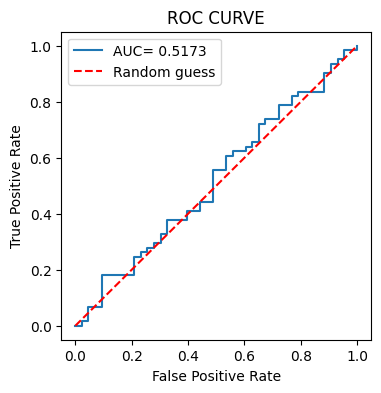

In [442]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (roc_curve,auc,precision_recall_curve,average_precision_score )
#=========================================
# Setting features
#=========================================
X_3_2=df_3[["Lag1","Lag2","Lag3", "Lag4", "Lag5","Volume"]]
y_3_2=df_3["Direction"].map({"Up":1,"Down":0})

#=========================================
# Splitting data based on specific year
#=========================================
train_id = (df_3['Year'] <= 2008) # returns true for years equal or below 2008, so used as a index
test_id  = (df_3['Year'] > 2008)

# using the train and test indicies. 

X_train_3_2, X_test_3_2 = X_3_2.loc[train_id], X_3_2.loc[test_id]
y_train_3_2, y_test_3_2 = y_3_2.loc[train_id], y_3_2.loc[test_id]

# printing the shape of training and testing set 
print("Train shape:", X_train_3_2.shape, " Test shape:", X_test_3_2.shape)

#=========================================
# fitting a logistic regression 
#=========================================

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_3_2, y_train_3_2)


#=========================================
# --- Predict on test set ---
#=========================================
y_pred = log_reg.predict(X_test_3_2)
y_prob = log_reg.predict_proba(X_test_3_2)[:, 1] # it returns the probability for the 1 cases. can also be changed to 0


#=========================================
#  Evaluation 
#=========================================

# Confusion matrix
tn,fp,fn,tp = confusion_matrix(y_test_3_4, y_pred_3_4).ravel() # ravel assignes the values to the variables. 

# Print confusion matrix
print("Confusion Matrix:")
print(f"[[TN={tn}, FP={fp}]")
print(f" [FN={fn}, TP={tp}]]\n")

print("\nTest accuracy:", round(accuracy_score(y_test_3_2, y_pred),3))


#=========================================
#  Plotting ROC and AUC
#=========================================

fpr,tpr,threshold = roc_curve(y_test_3_2,y_prob)

roc_auc=auc(fpr,tpr)
print("AUC:", roc_auc)
#Plotting ROC
plt.figure(figsize=(4,4))
plt.plot(fpr, tpr,label=f'AUC= {roc_auc:.4f}')
plt.plot([0,1],[0,1], "r--", label="Random guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE')
plt.legend()
plt.tight_layout
plt.show()

🔹 CONFUSION MATRIX
[[TN=7, FP=36]
 [FN=8, TP=53]]

Interpretation of counts:
- TN (7): correctly predicted 'Down' when it was actually 'Down'.
- FP (36): predicted 'Up' when it was actually 'Down' (false alarm).
- FN (8): predicted 'Down' when it was actually 'Up' (missed positive).
- TP (53): correctly predicted 'Up' when it was actually 'Up'.

🔹 KEY PERFORMANCE METRICS AND INTERPRETATIONS
- Accuracy: 0.577
  → Proportion of all predictions the model got right.
  → High accuracy alone can be misleading if the dataset is imbalanced.

- Precision: 0.596
  → Of all predicted 'Up' (positive) cases, this is the fraction that were truly 'Up'.
  → High precision means few false alarms; low precision means many false positives.

- Recall (Sensitivity): 0.869
  → Of all actual 'Up' cases, this is the fraction the model identified correctly.
  → High recall means the model catches most positives but might include more false positives.

- Specificity (True Negative Rate): 0.163
  → Of all actual

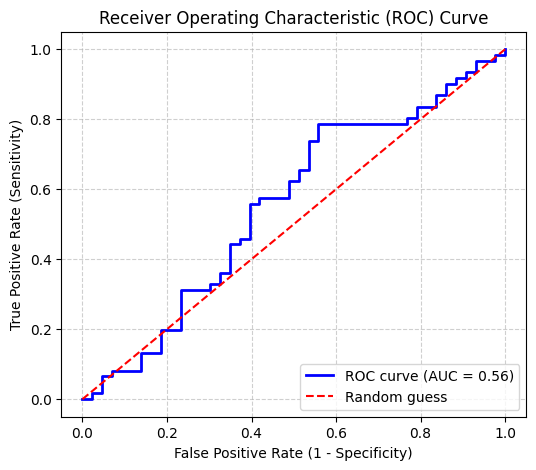

⚠️ REFLECTIONS AND POTENTIAL PITFALLS
- Moderate F1 score.
  → Indicates trade-offs between catching positives and avoiding false positives.

- Always interpret FP (false positives) and FN (false negatives) in domain context.
  → Depending on your application, missing a positive (FN) may be far more costly than a false alarm (FP).
  → Consider adjusting the decision threshold to balance these trade-offs.

End of detailed performance report.



In [295]:
interpret_model_performance(y_test_3_2, y_pred, y_prob, plot_roc=True)

### Solution

Train shape: (985, 6)  Test shape: (104, 6)
Test Accuracy: 0.462
AUC: 0.517
Confusion Matrix:
 [[31 12]
 [44 17]]


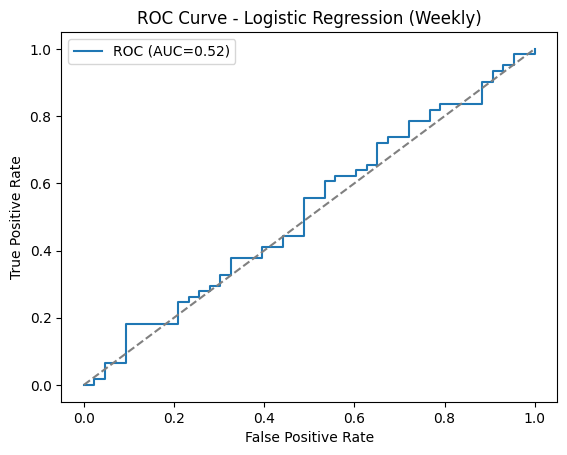

In [269]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt


# --- Define predictors and target ---
X = df[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
y = (df['Direction'] == 'Up').astype(int)

# --- Split into training and test sets ---
train = df['Year'] < 2009
test = ~train
X_train, X_test = X[train], X[test]
y_train, y_test = y[train], y[test]

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# --- Fit Logistic Regression ---
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# --- Predict on test set ---
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

# --- Evaluation metrics ---
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Test Accuracy: {acc:.3f}")
print(f"AUC: {auc:.3f}")
print("Confusion Matrix:\n", cm)

# --- Optional ROC curve plot ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"ROC (AUC={auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Weekly)")
plt.legend()
plt.show()


 #Comments:
# - Logistic model performs near random (Accuracy ≈ 0.46, AUC ≈ 0.52).
# - Coefficients fail to capture meaningful pattern from Lag1–Lag5 and Volume.
# - ROC curve is step-like and hugs y=x, indicating weak separation between classes.


### Exercise 3.3: Logistic Regression Using Lag2 Only

* Define predictor as Lag1 and Lag2 and the target as Direction.

* Split data into training and test as in previous exercise. Fit a logistic regression model on the training set.

* Predict Direction on the test set.

* Report accuracy, confusion matrix, and AUC.

* Plot the ROC curve and interpret whether prediction improves compared to full logistic regression.

Train shape: (985, 2)  Test shape: (104, 2)
Confusion Matrix:
[[TN=7, FP=36]
 [FN=8, TP=53]]


Test accuracy: 0.577
AUC: 0.5559


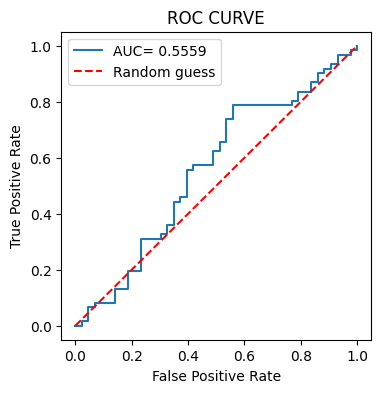

In [291]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (roc_curve,auc,precision_recall_curve,average_precision_score )
#=========================================
# Setting features
#=========================================
X_3_3=df_3[["Lag1","Lag2"]]
y_3_3=df_3["Direction"].map({"Up":1,"Down":0})

#=========================================
# Splitting data based on specific year
#=========================================
train_id = (df_3['Year'] <= 2008) # returns true for years equal or below 2008, so used as a index
test_id  = (df_3['Year'] > 2008)

# using the train and test indicies. 

X_train_3_3, X_test_3_3 = X_3_3.loc[train_id], X_3_3.loc[test_id]
y_train_3_3, y_test_3_3 = y_3_3.loc[train_id], y_3_3.loc[test_id]

# printing the shape of training and testing set 
print("Train shape:", X_train_3_3.shape, " Test shape:", X_test_3_3.shape)

#=========================================
# fitting a logistic regression 
#=========================================

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_3_3, y_train_3_3)


#=========================================
# --- Predict on test set ---
#=========================================
y_pred = log_reg.predict(X_test_3_3)
y_prob = log_reg.predict_proba(X_test_3_3)[:, 1] # it returns the probability for the 1 cases. can also be changed to 0


#=========================================
#  Evaluation 
#=========================================

# Confusion matrix (rows=predicted, cols=actual)
tn,fp,fn,tp = confusion_matrix(y_test_3_3, y_pred).ravel() # ravel assignes the values to the variables. 

# Print confusion matrix
print("Confusion Matrix:")
print(f"[[TN={tn}, FP={fp}]")
print(f" [FN={fn}, TP={tp}]]\n")



print("\nTest accuracy:", round(accuracy_score(y_test_3_3, y_pred),3))


#=========================================
#  Plotting ROC and AUC
#=========================================

fpr,tpr,threshold = roc_curve(y_test_3_3,y_prob)

roc_auc_3=auc(fpr,tpr)
print("AUC:",round(roc_auc_3,4))



#Plotting ROC
plt.figure(figsize=(4,4))
plt.plot(fpr, tpr,label=f'AUC= {roc_auc:.4f}')
plt.plot([0,1],[0,1], "r--", label="Random guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE')
plt.legend()
plt.tight_layout
plt.show()

🔹 CONFUSION MATRIX
[[TN=7, FP=36]
 [FN=8, TP=53]]

Interpretation of counts:
- TN (7): correctly predicted 'Down' when it was actually 'Down'.
- FP (36): predicted 'Up' when it was actually 'Down' (false alarm).
- FN (8): predicted 'Down' when it was actually 'Up' (missed positive).
- TP (53): correctly predicted 'Up' when it was actually 'Up'.

🔹 KEY PERFORMANCE METRICS AND INTERPRETATIONS
- Accuracy: 0.577
  → Proportion of all predictions the model got right.
  → High accuracy alone can be misleading if the dataset is imbalanced.

- Precision: 0.596
  → Of all predicted 'Up' (positive) cases, this is the fraction that were truly 'Up'.
  → High precision means few false alarms; low precision means many false positives.

- Recall (Sensitivity): 0.869
  → Of all actual 'Up' cases, this is the fraction the model identified correctly.
  → High recall means the model catches most positives but might include more false positives.

- Specificity (True Negative Rate): 0.163
  → Of all actual

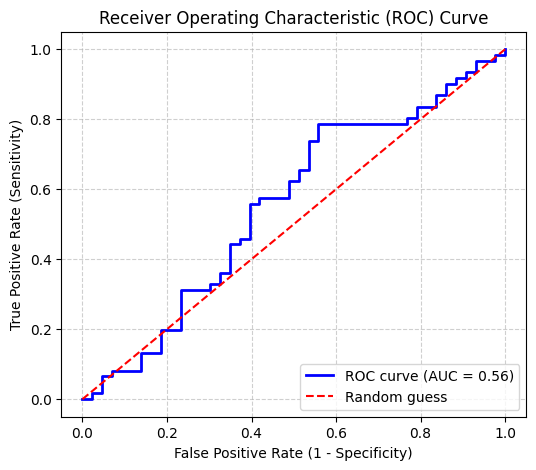

⚠️ REFLECTIONS AND POTENTIAL PITFALLS
- Moderate F1 score.
  → Indicates trade-offs between catching positives and avoiding false positives.

- Always interpret FP (false positives) and FN (false negatives) in domain context.
  → Depending on your application, missing a positive (FN) may be far more costly than a false alarm (FP).
  → Consider adjusting the decision threshold to balance these trade-offs.

End of detailed performance report.



In [296]:
interpret_model_performance(y_test_3_3, y_pred, y_prob, plot_roc=True)

### Solution

Test Accuracy: 0.577
AUC: 0.556
Confusion Matrix:
 [[ 7 36]
 [ 8 53]]


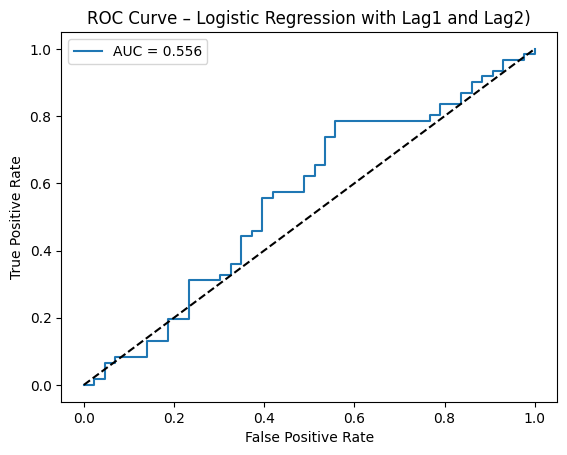

In [29]:
# --- Define predictors and target ---
X = df[["Lag1", "Lag2"]]
y = (df["Direction"] == "Up").astype(int)

# --- Train/Test Split ---
train = df["Year"] < 2009
X_train, X_test = X[train], X[~train]
y_train, y_test = y[train], y[~train]

# --- Fit Logistic Regression ---
log_reg = LogisticRegression(penalty=None)
log_reg.fit(X_train, y_train)

# --- Predict Probabilities and Classes ---
y_pred_prob = log_reg.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob > 0.5).astype(int)

# --- Evaluate ---
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Accuracy: {acc:.3f}")
print(f"AUC: {auc:.3f}")
print("Confusion Matrix:\n", cm)

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression with Lag1 and Lag2)")
plt.legend()
plt.show()

# Comments:
# - The model achieves ~57.7% accuracy, but mostly by predicting "Up" often.
# - AUC = 0.556 indicates somewhat weak ability to separate "Up" from "Down".
# - The class imbalance (more 'Up' weeks) explains the asymmetric confusion matrix.


### Exercise 3.4: Linear Discriminant Analysis (LDA)

* Using Lag1 and Lag2 predictors, fit an LDA model on the training data.

* Predict the Direction on the test set.

* Compute and report the test accuracy, AUC, and confusion matrix.

* Compare the LDA results with logistic regression: does it improve classification?

Train shape: (985, 2)  Test shape: (104, 2)
Confusion Matrix:
[[TN=7, FP=36]
 [FN=8, TP=53]]


Test accuracy: 0.577
AUC: 0.5566


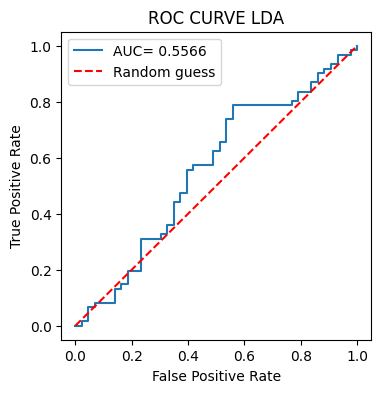

In [329]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, roc_auc_score, roc_curve,auc

import pandas as pd

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#=========================================
# Setting features
#=========================================
X_3_4=df_3[["Lag1","Lag2"]]
y_3_4=df_3["Direction"].map({"Up":1,"Down":0})

#=========================================
# Splitting data based on specific year
#=========================================
train_id = (df_3['Year'] <= 2008) # returns true for years equal or below 2008, so used as a index
test_id  = (df_3['Year'] > 2008)

# using the train and test indicies. 

X_train_3_4, X_test_3_4 = X_3_4.loc[train_id], X_3_4.loc[test_id]
y_train_3_4, y_test_3_4 = y_3_4.loc[train_id], y_3_4.loc[test_id]

# printing the shape of training and testing set 
print("Train shape:", X_train_3_4.shape, " Test shape:", X_test_3_4.shape)

#=========================================
# fitting a linear discriminant analysis LDA
#=========================================

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_3_4, y_train_3_4)


#=========================================
# --- Predict on test set ---
#=========================================
y_pred_3_4 = lda.predict(X_test_3_4)
y_prob_3_4 = lda.predict_proba(X_test_3_4)[:, 1] # it returns the probability for the 1 cases. can also be changed to 0


#=========================================
#  Evaluation 
#=========================================

# Confusion matrix (rows=predicted, cols=actual)
tn,fp,fn,tp = confusion_matrix(y_test_3_4, y_pred_3_4).ravel() # ravel assignes the values to the variables. 

# Print confusion matrix
print("Confusion Matrix:")
print(f"[[TN={tn}, FP={fp}]")
print(f" [FN={fn}, TP={tp}]]\n")



print("\nTest accuracy:", round(accuracy_score(y_test_3_4, y_pred_3_4),3))


#=========================================
#  Plotting ROC and AUC
#=========================================

fpr_4,tpr_4,threshold_4 = roc_curve(y_test_3_4,y_prob_3_4)

roc_auc_4=auc(fpr_4,tpr_4)
print("AUC:",round(roc_auc_4,4))




#Plotting ROC
plt.figure(figsize=(4,4))
plt.plot(fpr_4, tpr_4,label=f'AUC= {roc_auc_4:.4f}')
plt.plot([0,1],[0,1], "r--", label="Random guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE LDA')
plt.legend()
plt.tight_layout
plt.show()


#### INTERPRETATION FUNCTION

🔹 CONFUSION MATRIX
[[TN=7, FP=36]
 [FN=8, TP=53]]

Interpretation of counts:
- TN (7): correctly predicted 'Down' when it was actually 'Down'.
- FP (36): predicted 'Up' when it was actually 'Down' (false alarm).
- FN (8): predicted 'Down' when it was actually 'Up' (missed positive).
- TP (53): correctly predicted 'Up' when it was actually 'Up'.

🔹 KEY PERFORMANCE METRICS AND INTERPRETATIONS
- Accuracy: 0.577
  → Proportion of all predictions the model got right.
  → High accuracy alone can be misleading if the dataset is imbalanced.

- Precision: 0.596
  → Of all predicted 'Up' (positive) cases, this is the fraction that were truly 'Up'.
  → High precision means few false alarms; low precision means many false positives.

- Recall (Sensitivity): 0.869
  → Of all actual 'Up' cases, this is the fraction the model identified correctly.
  → High recall means the model catches most positives but might include more false positives.

- Specificity (True Negative Rate): 0.163
  → Of all actual

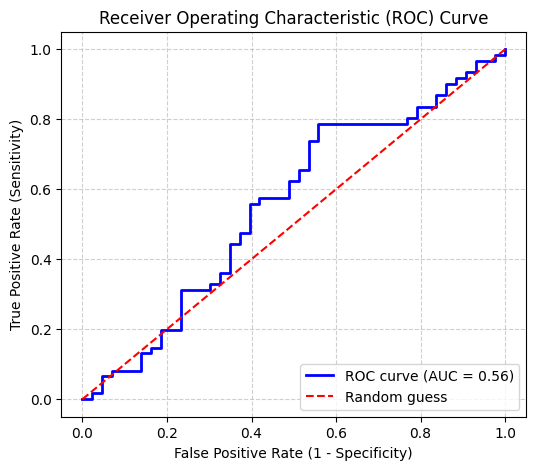

⚠️ REFLECTIONS AND POTENTIAL PITFALLS
- Moderate F1 score.
  → Indicates trade-offs between catching positives and avoiding false positives.

- Always interpret FP (false positives) and FN (false negatives) in domain context.
  → Depending on your application, missing a positive (FN) may be far more costly than a false alarm (FP).
  → Consider adjusting the decision threshold to balance these trade-offs.

End of detailed performance report.



In [303]:
interpret_model_performance(y_test_3_4, y_pred_3_4, y_prob_3_4, plot_roc=True)

### Solution

LDA Test Accuracy: 0.577
AUC: 0.557
Confusion Matrix:
 [[ 7 36]
 [ 8 53]]


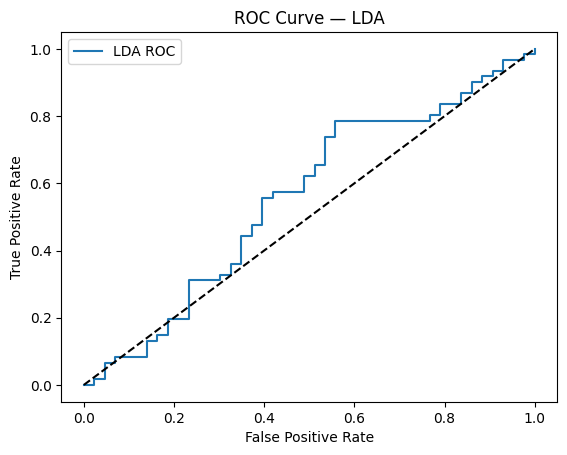

In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


# --- Fit LDA ---
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# --- Predict ---
y_pred = lda.predict(X_test)
y_prob = lda.predict_proba(X_test)[:, 1]

# --- Evaluate ---
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f"LDA Test Accuracy: {acc:.3f}")
print(f"AUC: {auc:.3f}")
print("Confusion Matrix:\n", cm)

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="LDA ROC")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — LDA")
plt.legend()
plt.show()

# --- Comments ---
# LDA Test Accuracy: 0.577 — only slightly better than random guessing (≈0.5).
# AUC: 0.557 — marginal discriminative power, meaning LDA separates "Up"/"Down" weakly.
# Confusion Matrix: [[7 36], [8 53]] → model predicts "Up" frequently, missing many "Down" weeks.



### Exercise 3.5: Quadratic Discriminant Analysis (QDA)

* Using Lag1 and Lag2 predictors, fit a QDA model on the training set.

* Predict Direction on the test set.

* Compute test accuracy, AUC, and confusion matrix.

* Compare performance with LDA. Discuss differences in predictive behavior.

Train shape: (985, 2)  Test shape: (104, 2)
Confusion Matrix:
[[TN=7, FP=36]
 [FN=10, TP=51]]


Test accuracy: 0.558
AUC: 0.4712


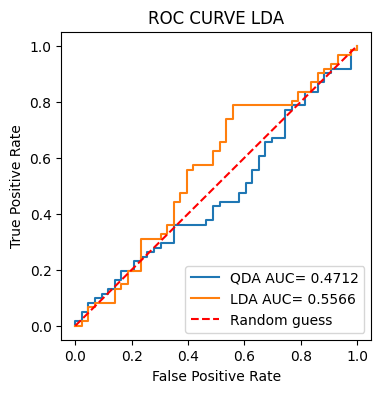

In [328]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, auc
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import warnings
warnings.filterwarnings('ignore')

#=========================================
# Setting features
#=========================================
X_3_5=df_3[["Lag1","Lag2"]]
y_3_5=df_3["Direction"].map({"Up":1,"Down":0})

#=========================================
# Splitting data based on specific year
#=========================================
train_id = (df_3['Year'] <= 2008) # returns true for years equal or below 2008, so used as a index
test_id  = (df_3['Year'] > 2008)

# using the train and test indicies. 

X_train_3_5, X_test_3_5 = X_3_5.loc[train_id], X_3_5.loc[test_id]
y_train_3_5, y_test_3_5 = y_3_5.loc[train_id], y_3_5.loc[test_id]

# printing the shape of training and testing set 
print("Train shape:", X_train_3_5.shape, " Test shape:", X_test_3_5.shape)

#=========================================
# fitting a linear discriminant analysis LDA
#=========================================

QDA = QuadraticDiscriminantAnalysis()
QDA.fit(X_train_3_5, y_train_3_5)


#=========================================
# --- Predict on test set ---
#=========================================
y_pred_3_5 = QDA.predict(X_test_3_5)
y_prob_3_5 = QDA.predict_proba(X_test_3_5)[:, 1] # it returns the probability for the 1 cases. can also be changed to 0


#=========================================
#  Evaluation 
#=========================================

# Confusion matrix (rows=predicted, cols=actual)
tn,fp,fn,tp = confusion_matrix(y_test_3_5, y_pred_3_5).ravel() # ravel assignes the values to the variables. 

# Print confusion matrix
print("Confusion Matrix:")
print(f"[[TN={tn}, FP={fp}]")
print(f" [FN={fn}, TP={tp}]]\n")



print("\nTest accuracy:", round(accuracy_score(y_test_3_5, y_pred_3_5),3))


#=========================================
#  Plotting ROC and AUC
#=========================================

fpr_5,tpr_5,threshold_5 = roc_curve(y_test_3_5,y_prob_3_5)

roc_auc_5=auc(fpr_5,tpr_5)
print("AUC:",round(roc_auc_5,4))



#Plotting ROC
plt.figure(figsize=(4,4))
plt.plot(fpr_5, tpr_5,label=f'QDA AUC= {roc_auc_5:.4f}')
plt.plot(fpr_4, tpr_4,label=f'LDA AUC= {roc_auc_4:.4f}')
plt.plot([0,1],[0,1], "r--", label="Random guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE LDA')
plt.legend()
plt.tight_layout
plt.show()


### Solution

In [323]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# Fit QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

# Predict
y_pred = qda.predict(X_test)
y_prob = qda.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f"QDA Test Accuracy: {acc:.3f}")
print(f"AUC: {auc:.3f}")
print("Confusion Matrix:\n", cm)

# --- Comments ---
# Test Accuracy of 0.558 — slightly worse than LDA (0.577); QDA is overfitting small dataset.
# AUC of 0.471 — below 0.5, suggesting poor separation of "Up" vs "Down".
# Confusion Matrix shows many misclassifications for "Down" (7 correct vs 36 wrong) and "Up" (51 correct vs 10 wrong).
# Compared to LDA, QDA’s flexible covariance modeling does not improve predictions here; signal is weak and sample size is small.
# Conclusion: For weekly market data with just Lag1 & Lag2, simpler linear boundaries (LDA) outperform QDA.



QDA Test Accuracy: 0.433
AUC: 0.538
Confusion Matrix:
 [[33 10]
 [49 12]]


### Exercise 3.6: K-Nearest Neighbors (KNN) Classification

* Using Lag1 and Lag2 as predictors and Pipeline with StandardScaler, fit KNN classifier with k=5 on the training data.

* Predict Direction on the test set.

* Compute test accuracy, AUC, and confusion matrix.

* Comment on KNN performance and how it compares to LDA/QDA.

Train shape: (985, 2)  Test shape: (104, 2)
Confusion Matrix:
[[TN=22, FP=21]
 [FN=32, TP=29]]


Test accuracy: 0.49
AUC: 0.5078


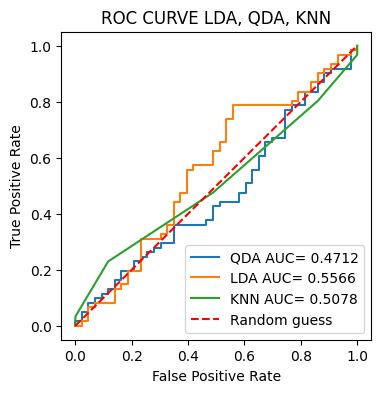

In [331]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, auc
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


#=========================================
# Setting features
#=========================================
X_3_6=df_3[["Lag1","Lag2"]]
y_3_6=df_3["Direction"].map({"Up":1,"Down":0})

#=========================================
# Splitting data based on specific year
#=========================================
train_id = (df_3['Year'] <= 2008) # returns true for years equal or below 2008, so used as a index
test_id  = (df_3['Year'] > 2008)

# using the train and test indicies. 

X_train_3_6, X_test_3_6 = X_3_5.loc[train_id], X_3_6.loc[test_id]
y_train_3_6, y_test_3_6 = y_3_6.loc[train_id], y_3_6.loc[test_id]

# printing the shape of training and testing set 
print("Train shape:", X_train_3_6.shape, " Test shape:", X_test_3_6.shape)


#=========================================
# Makeing pipe
#=========================================
knn_pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))])

#=========================================
# fitting a Knn
#=========================================


knn_pipe.fit(X_train_3_6, y_train_3_6)


#=========================================
# --- Predict on test set ---
#=========================================
y_pred_3_6 = knn_pipe.predict(X_test_3_6)
y_prob_3_6 = knn_pipe.predict_proba(X_test_3_6)[:, 1] # it returns the probability for the 1 cases. can also be changed to 0


#=========================================
#  Evaluation 
#=========================================

# Confusion matrix (rows=predicted, cols=actual)
tn,fp,fn,tp = confusion_matrix(y_test_3_6, y_pred_3_6).ravel() # ravel assignes the values to the variables. 

# Print confusion matrix
print("Confusion Matrix:")
print(f"[[TN={tn}, FP={fp}]")
print(f" [FN={fn}, TP={tp}]]\n")



print("\nTest accuracy:", round(accuracy_score(y_test_3_6, y_pred_3_6),3))


#=========================================
#  Plotting ROC and AUC
#=========================================

fpr_6,tpr_6,threshold = roc_curve(y_test_3_6,y_prob_3_6)

roc_auc_6=auc(fpr_6,tpr_6)
print("AUC:",round(roc_auc_6,4))



#Plotting ROC
plt.figure(figsize=(4,4))
plt.plot(fpr_5, tpr_5,label=f'QDA AUC= {roc_auc_5:.4f}')
plt.plot(fpr_4, tpr_4,label=f'LDA AUC= {roc_auc_4:.4f}')
plt.plot(fpr_6, tpr_6,label=f'KNN AUC= {roc_auc_6:.4f}')
plt.plot([0,1],[0,1], "r--", label="Random guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE LDA, QDA, KNN')
plt.legend()
plt.tight_layout
plt.show()






### Solution

In [325]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# --- KNN with scaling (k=5) ---
knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f"KNN Test Accuracy: {acc:.3f}")
print(f"AUC: {auc:.3f}")
print("Confusion Matrix:\n", cm)

# KNN performs roughly at chance level (accuracy ~49%, AUC ~0.51), barely better than random guessing.
# The confusion matrix shows many misclassifications in both classes; neither "Up" nor "Down" is predicted particularly well.
# Possible reasons: small sample size, weak predictive signal in Lag1/Lag2, or KNN's sensitivity to noisy features.
# Scaling was applied, so poor performance is not due to feature magnitude differences.
# Compared to LDA (accuracy 0.577) and QDA (accuracy 0.558), KNN underperforms here—linear methods handle this dataset better.



KNN Test Accuracy: 0.510
AUC: 0.527
Confusion Matrix:
 [[22 21]
 [30 31]]


### Exercise 3.7: Challenge-Lasso Logistic Regression

* Fit a Lasso logistic regression on the training set using all predictors.

* In above step, set cv=5, solver='saga' and penalty='l1'.

* Predict Direction on the test set.

* Compute accuracy, confusion matrix, and AUC.

* Identify selected features (non-zero coefficients) and discuss them.


In [341]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, auc
from sklearn.pipeline import Pipeline

#=========================================
# Setting features
#=========================================
X_3_7=df_3[["Lag1","Lag2","Lag3", "Lag4", "Lag5","Volume"]]
y_3_7=df_3["Direction"].map({"Up":1,"Down":0})

#=========================================
# Makeing pipe
#=========================================
las_log_pipe = Pipeline([(
    'scaler', StandardScaler()),
    ('las_log', LogisticRegressionCV(cv=5,solver="saga",penalty="l1"),
     )])


#=========================================
# Fitting model
#=========================================
las_log_pipe=LogisticRegressionCV(cv=5,solver="saga",penalty="l1")

las_log_pipe.fit(X_train_3_6,y_train_3_6)
#=========================================
# Predicting and calc prob of the model 
#=========================================
y_pred_3_7=las_log_pipe.predict(X_test_3_6)

y_prob_3_7 = las_log_pipe.predict_proba(X_test_3_6)[:, 1] # it returns the probability for the 1 cases. can also be changed to 0


#=========================================
#  Evaluation 
#=========================================

# Confusion matrix (rows=predicted, cols=actual)
tn_7,fp_7,fn_7,tp_7 = confusion_matrix(y_test_3_6, y_pred_3_7).ravel() # ravel assignes the values to the variables. 

# Print confusion matrix
print("Confusion Matrix:")
print(f"[[TN={tn_7}, FP={fp_7}]")
print(f" [FN={fn_7}, TP={tp_7}]]\n")

print("\nTest accuracy:", round(accuracy_score(y_test_3_6, y_pred_3_7),3))

#=========================================
#  AUC
#=========================================

fpr_7,tpr_7,threshold = roc_curve(y_test_3_6,y_prob_3_7)

roc_auc_7=auc(fpr_7,tpr_7)
print("AUC:",round(roc_auc_7,4))

#=========================================
#  Getting the coefficient
#=========================================

coefficient_las_log = las_log_pipe.coef_


print("Selected feature:", coefficient_las_log)

# [[0. 0.]]= no features are selected 








Confusion Matrix:
[[TN=0, FP=43]
 [FN=0, TP=61]]


Test accuracy: 0.587
AUC: 0.5
Selected feature: [[0. 0.]]


### Solution

In [8]:
from sklearn.linear_model import LogisticRegressionCV

# --- Define predictors and target ---
X = df[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
y = (df['Direction'] == 'Up').astype(int)

# --- Split into training and test sets ---
train = df['Year'] < 2009
test = ~train
X_train, X_test = X[train], X[test]
y_train, y_test = y[train], y[test]


# Pipeline with scaling + Lasso Logistic
lasso_logit = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegressionCV(
        cv=5, penalty='l1', solver='saga'))
])

lasso_logit.fit(X_train, y_train)
y_pred = lasso_logit.predict(X_test)
y_prob = lasso_logit.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

# Coefficients
coef = lasso_logit.named_steps['logit'].coef_.flatten()
selected_features = [f"X{i+1}" for i, c in enumerate(coef) if c != 0]

print(f"Lasso Logistic Test Accuracy: {acc:.3f}")
print(f"AUC: {auc:.3f}")
print("Confusion Matrix:\n", cm)
print("Selected features:", selected_features)

# --- Comments ---
# Lasso Logistic selected no features: all coefficients shrunk to zero.
# As a result, the model predicts a constant class (all "Up"), leading to a confusion matrix with zero true negatives/positives.
# Test Accuracy (0.587) reflects the majority class proportion, not real predictive performance.
# AUC of 0.5 indicates no discriminative ability — Lasso over-regularized given weak signal or limited sample size.




Lasso Logistic Test Accuracy: 0.587
AUC: 0.500
Confusion Matrix:
 [[ 0 43]
 [ 0 61]]
Selected features: []


## 4: Credit Risk Classification

In this section we will apply classification methods on German credit risk dataset. While previous exercise set dealt with numerical predictor, one added complexity in this exercise set is the presence of both numerical and categorical features.

### Exercise 4.1: Data Loading & Exploration

* Load the German Credit dataset (credit-g) from sklearn.datasets fetch_openml.

* Display the first few rows and check the shape of the data.

* Inspect class distribution (Good vs. Bad).

* Summarize numeric features (mean, median, std, min, max).

* Optionally, visualize categorical features with bar plots.

In [2]:
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np

# 1. Load data
data = fetch_openml('credit-g', version=1, as_frame=True)
df_4_1 = data.frame


#Inspecting data 
print("Shape", df_4_1.shape)
print("\nColumns in df_4:\n", df_4_1.columns)
print("\n\nFirst 5 rows:\n", df_4_1.head(5))

# Summary statistics
summary_stats = df_4_1.select_dtypes(include="number").describe().T[['mean','std','min','max']]
print("\n\nSummary Statistics:\n",summary_stats)

# Counting variables for target
print("\n\nBalance of target:\n", df_4_1["class"].value_counts())
#balance ratio 
ratio=df_4_1["class"].value_counts().min()/df_4_1["class"].value_counts().max()
# Print results


# Classify balance level with ratio included in each message
if ratio < 0.40:
    print(f"\nDataset is IMBALANCED (severe class imbalance) accuracy in NOT considered a reasonable baseline. Ratio = {ratio:.2f}")
elif ratio < 0.8:
    print(f"\nDataset is MILDLY IMBALANCED, accuracy is reasonable baseline (moderate class imbalance). Ratio = {ratio:.2f}")
else:
    print(f"\nDataset is BALANCED. Ratio = {ratio:.2f}")

df_4_1.head(40)


Shape (1000, 21)

Columns in df_4:
 Index(['checking_status', 'duration', 'credit_history', 'purpose',
       'credit_amount', 'savings_status', 'employment',
       'installment_commitment', 'personal_status', 'other_parties',
       'residence_since', 'property_magnitude', 'age', 'other_payment_plans',
       'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone',
       'foreign_worker', 'class'],
      dtype='object')


First 5 rows:
   checking_status  duration                  credit_history  \
0              <0         6  critical/other existing credit   
1        0<=X<200        48                   existing paid   
2     no checking        12  critical/other existing credit   
3              <0        42                   existing paid   
4              <0        24              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv           1169  no known savings        >=7   
1             radio/t

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad
5,no checking,36,existing paid,education,9055,no known savings,1<=X<4,2,male single,none,...,no known property,35,none,for free,1,unskilled resident,2,yes,yes,good
6,no checking,24,existing paid,furniture/equipment,2835,500<=X<1000,>=7,3,male single,none,...,life insurance,53,none,own,1,skilled,1,none,yes,good
7,0<=X<200,36,existing paid,used car,6948,<100,1<=X<4,2,male single,none,...,car,35,none,rent,1,high qualif/self emp/mgmt,1,yes,yes,good
8,no checking,12,existing paid,radio/tv,3059,>=1000,4<=X<7,2,male div/sep,none,...,real estate,61,none,own,1,unskilled resident,1,none,yes,good
9,0<=X<200,30,critical/other existing credit,new car,5234,<100,unemployed,4,male mar/wid,none,...,car,28,none,own,2,high qualif/self emp/mgmt,1,none,yes,bad


### Solution

Shape of dataset: (1000, 21)
  checking_status  duration                  credit_history  \
0              <0         6  critical/other existing credit   
1        0<=X<200        48                   existing paid   
2     no checking        12  critical/other existing credit   
3              <0        42                   existing paid   
4              <0        24              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv           1169  no known savings        >=7   
1             radio/tv           5951              <100     1<=X<4   
2            education           2096              <100     4<=X<7   
3  furniture/equipment           7882              <100     4<=X<7   
4              new car           4870              <100     1<=X<4   

   installment_commitment     personal_status other_parties  ...  \
0                       4         male single          none  ...   
1                       2  female d

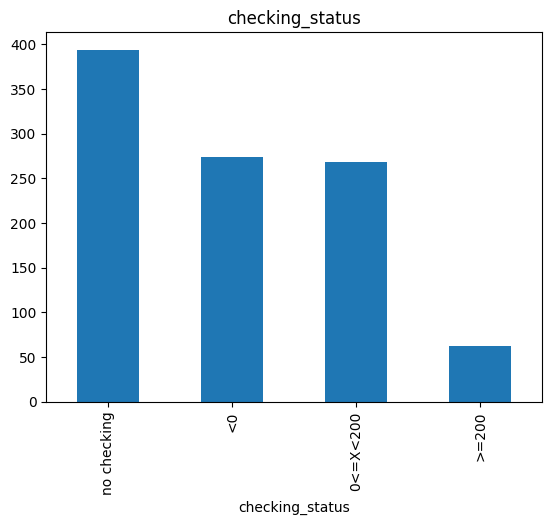

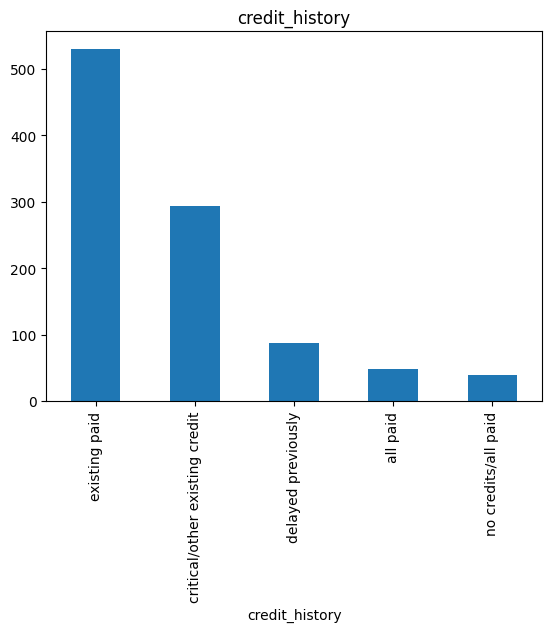

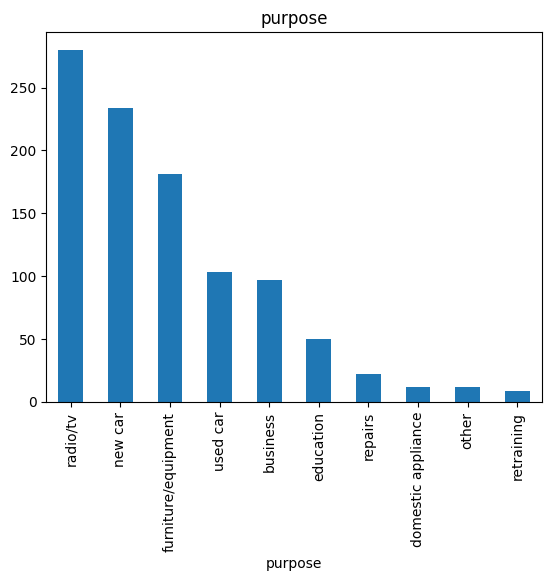

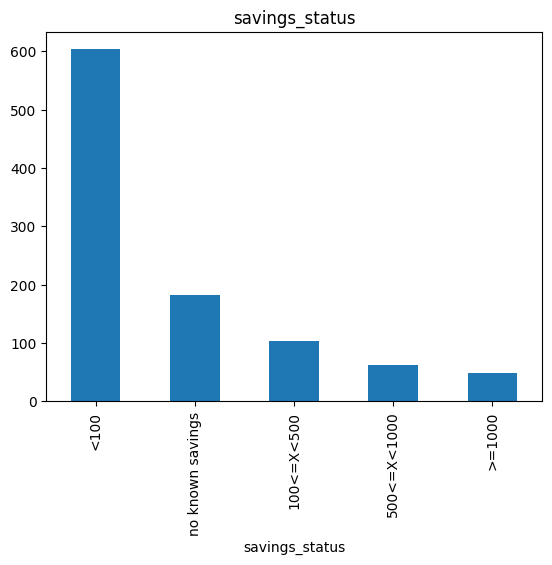

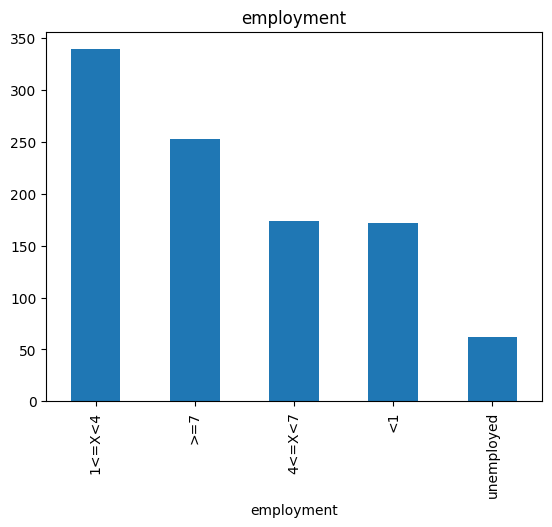

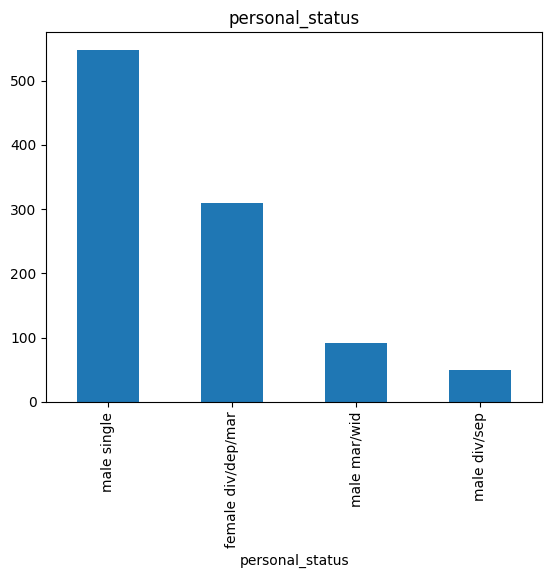

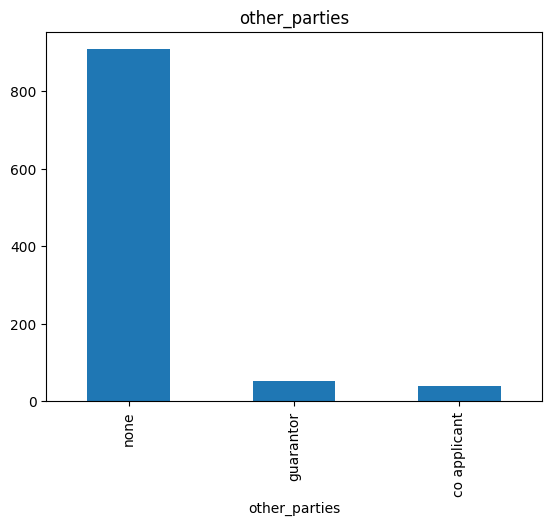

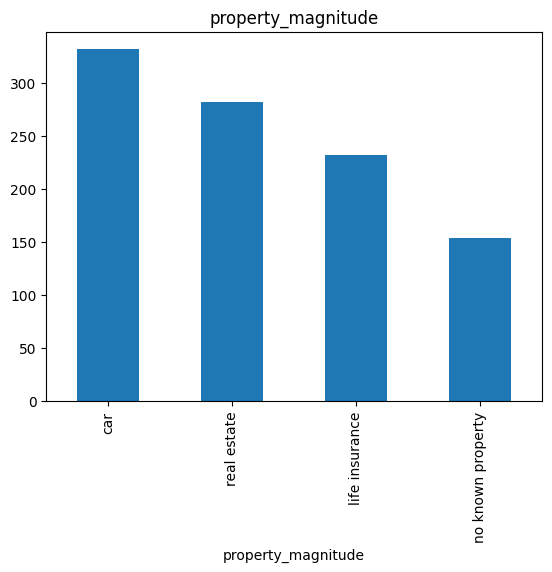

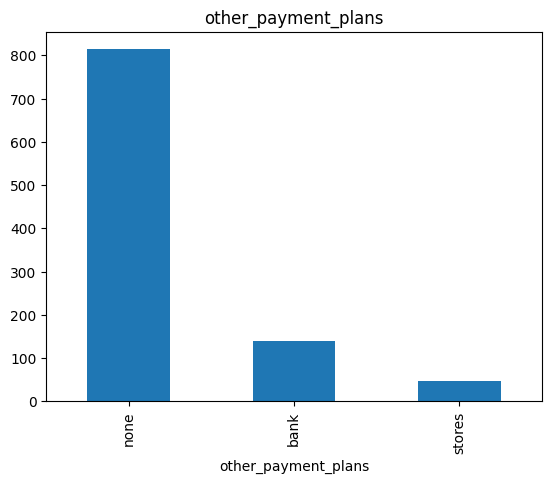

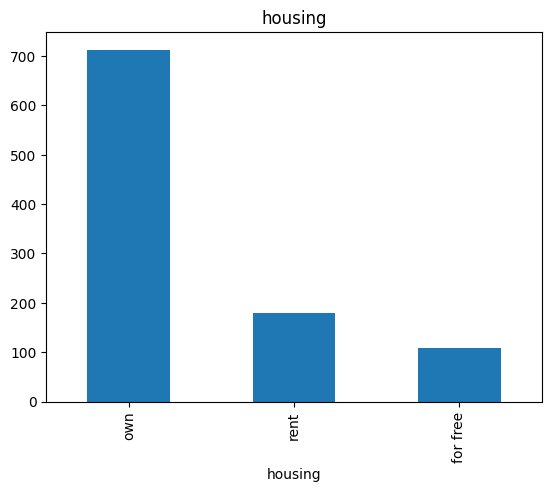

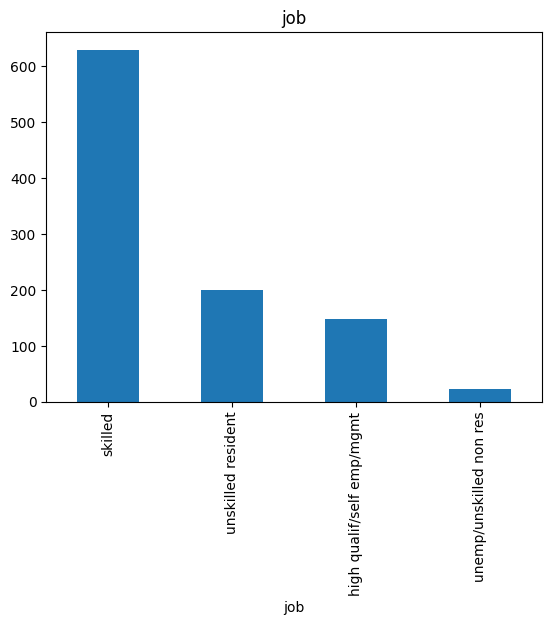

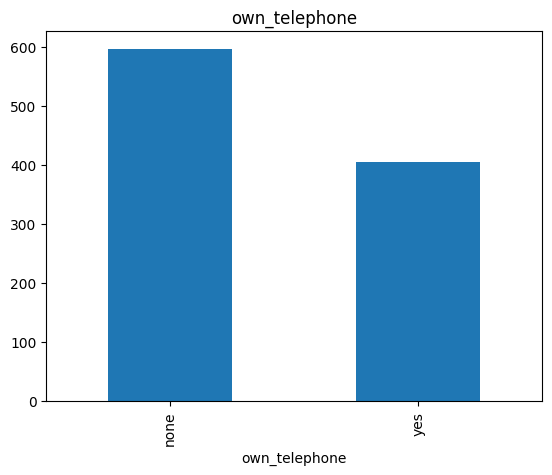

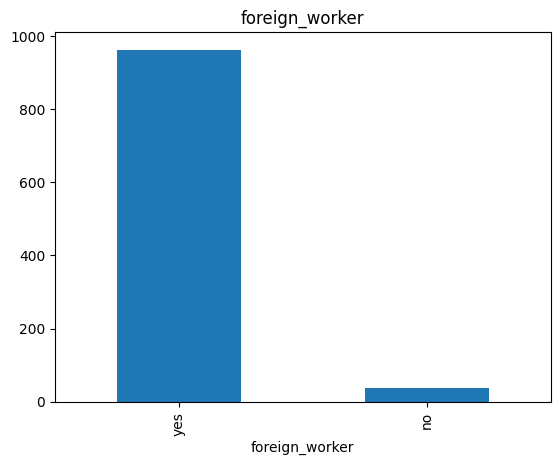

In [32]:
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np

# 1. Load data
data = fetch_openml('credit-g', version=1, as_frame=True)
df = data.frame


# 2. Display first few rows and shape
print("Shape of dataset:", df.shape)
print(df.head())

# 3. Check class distribution
print("\nClass distribution:")
print(df['class'].value_counts())

# 4. Summary statistics for numeric features
numeric_cols = df.select_dtypes(include='number').columns
print("\nSummary statistics for numeric columns:")
print(df[numeric_cols].describe().T)

# 5. Optional: visualize categorical features
import matplotlib.pyplot as plt

categorical_cols = df.select_dtypes(exclude='number').columns.drop('class')
for col in categorical_cols:
    df[col].value_counts().plot(kind='bar', title=col)
    plt.show()

# Dataset has 1000 rows and 20 features (numeric + categorical).
# Target variable 'class' is binary: Good (700) / Bad (300).
# Numeric features show various scales; some may need scaling for KNN or penalized regression.
# Categorical features have multiple levels — will need one-hot encoding for most models.
# Initial exploration suggests class imbalance is mild (~70/30), so accuracy is reasonable baseline.


### Exercise 4.2: Data Splitting

* Convert the target "class" to binary: "good" = 1, "bad" = 0.

* Convert categorical predictors to numeric using one-hot encoding (pd.get_dummies).

* Split data into training (70%) and test (30%) sets with train_test_split.

* Display basic info — number of predictors, class balance, and preview of encoded features.

In [381]:
y_4_1=df_4_1["class"].map({"good":1,"bad":0})
df_4_1_features = df_4_1.drop(columns=["class"])


df_4_1_one_hot_encoding = pd.get_dummies(
    df_4_1_features,
    columns=df_4_1_features.select_dtypes(include=["object","category"]).columns,
    prefix="one_hot_encoded",
    drop_first=True
)
# Features
y_4_1= df_4_1["class"].map({"good":1,"bad":0})
X_4_1 =df_4_1_one_hot_encoding
# Simple Train/Test Split (80% / 20%)
X_train_4_1, X_test_4_1, y_train_4_1, y_test_4_1 = train_test_split(
    X_4_1, y_4_1,
    test_size=0.30,
    random_state=42,  # sets seed for reproducibility
    shuffle=True      # set to False for time series data
)

# --- Automatically print dataset shapes ---
print("=== Train/Test Split Summary ===")
print(f"X_train shape: {X_train_4_1.shape}")
print(f"X_test shape:  {X_test_4_1.shape}")
print(f"y_train shape: {y_train_4_1.shape}")
print(f"y_test shape:  {y_test_4_1.shape}")
print(f"\nTraining set size: {len(y_train_4_1)} observations ({len(y_train_4_1)/len(y_4_1)*100:.1f}% of total)")
print(f"Test set size:     {len(y_test_4_1)} observations ({len(y_test_4_1)/len(y_4_1)*100:.1f}% of total)")


=== Train/Test Split Summary ===
X_train shape: (700, 48)
X_test shape:  (300, 48)
y_train shape: (700,)
y_test shape:  (300,)

Training set size: 700 observations (70.0% of total)
Test set size:     300 observations (30.0% of total)


### Solution

In [33]:
from sklearn.model_selection import train_test_split

# Convert categorical to string, then map to binary
df["class"] = df["class"].astype(str)
df["class"] = (df["class"] == "good").astype(int)

# --- One-hot encode categorical variables ---
df_encoded = pd.get_dummies(df, drop_first=True)

# --- Separate predictors and target ---
X = df_encoded.drop("class", axis=1)
y = df_encoded["class"]

# --- Split into train and test sets (70/30) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)


# --- Display summary info ---
print(f"Number of predictors: {X_train.shape[1]}")
print(f"Training samples: {len(y_train)}, Test samples: {len(y_test)}")
print("\nClass distribution (train):")
print(y_train.value_counts(normalize=True))
print("\nPreview of encoded predictors:")
print(X_train.head(5))


Number of predictors: 48
Training samples: 700, Test samples: 300

Class distribution (train):
class
1    0.701429
0    0.298571
Name: proportion, dtype: float64

Preview of encoded predictors:
     duration  credit_amount  installment_commitment  residence_since  age  \
541        24           2032                       4                4   60   
440        12           1884                       4                4   39   
482        30           3622                       4                4   57   
422        12            958                       2                3   47   
778        36           5711                       4                2   38   

     existing_credits  num_dependents  checking_status_<0  \
541                 2               1               False   
440                 1               1               False   
482                 2               1                True   
422                 2               2               False   
778                 2           

### Exercise 4.3: Logistic Regression

* Fit a logistic regression model on the training data.

* Predict class labels and probabilities on the test set.

* Compute accuracy, AUC, and confusion matrix.

* Plot the ROC curve.

* Inspect the largest coefficients — which predictors drive credit approval?

Confusion Matrix:
[[TN=41, FP=50]
 [FN=23, TP=186]]


Test accuracy: 0.757


Coefficient for log regression:
                   Feature  Log_Coef
0                duration -0.027874
1           credit_amount -0.000084
2  installment_commitment -0.275963
3         residence_since  0.140783
4                     age  0.021350
5        existing_credits  0.003762
6          num_dependents  0.020079
7      one_hot_encoded_<0 -0.604328


Coefficients with largest impact:
                                            Feature  Log_Coef
9                      one_hot_encoded_no checking  1.066304
10  one_hot_encoded_critical/other existing credit  0.611530
7                               one_hot_encoded_<0 -0.604328
14                         one_hot_encoded_new car -0.564534
39                            one_hot_encoded_none  0.462843
20                        one_hot_encoded_radio/tv  0.456466
41                             one_hot_encoded_own  0.436267
37                     one_hot_encoded_re

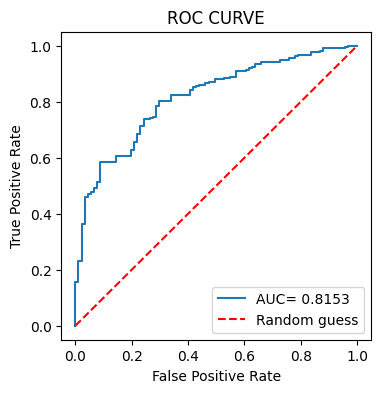

In [407]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (roc_curve,auc,precision_recall_curve,average_precision_score )

#=========================================
# fitting a logistic regression 
#=========================================

log_reg = LogisticRegression(penalty=None)
log_reg.fit(X_train_4_1, y_train_4_1)


#=========================================
# --- Predict on test set ---
#=========================================
y_pred = log_reg.predict(X_test_4_1)
y_prob = log_reg.predict_proba(X_test_4_1)[:, 1] # it returns the probability for the 1 cases. can also be changed to 0


#=========================================
#  Evaluation 
#=========================================

# Confusion matrix
tn,fp,fn,tp = confusion_matrix(y_test_4_1, y_pred).ravel() # ravel assignes the values to the variables. 

# Print confusion matrix
print("Confusion Matrix:")
print(f"[[TN={tn}, FP={fp}]")
print(f" [FN={fn}, TP={tp}]]\n")
print("\nTest accuracy:", round(accuracy_score(y_test_4_1, y_pred),3))
#=========================================
# Coefficients 
#=========================================
coef_log_4_3=log_reg.coef_

coef_comparison_log = pd.DataFrame({
    'Feature': X_4_1.columns,
    'Log_Coef': coef_log_4_3.ravel() #.ravel() converts it into a 1 dimension. 
})
print(f"\n\nCoefficient for log regression:\n",coef_comparison_log.head(8))

# Largest impact 
print("\n\nCoefficients with largest impact:\n",
       coef_comparison_log.sort_values(by="Log_Coef", 
        key=abs, 
        ascending=False).head(8))



#=========================================
#  Plotting ROC and AUC
#=========================================

fpr,tpr,threshold = roc_curve(y_test_4_1,y_prob)

roc_auc=auc(fpr,tpr)

print("\n\nAUC:",roc_auc)

#Plotting ROC
plt.figure(figsize=(4,4))
plt.plot(fpr, tpr,label=f'AUC= {roc_auc:.4f}')
plt.plot([0,1],[0,1], "r--", label="Random guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE')
plt.legend()
plt.tight_layout
plt.show()

### Solution

Test Accuracy: 0.757
AUC: 0.815
Confusion Matrix:
[[ 41  50]
 [ 23 186]]

Top 10 coefficients by magnitude:
                                          Feature  Coefficient
9                     checking_status_no checking     1.066274
10  credit_history_critical/other existing credit     0.611510
7                              checking_status_<0    -0.604325
14                                purpose_new car    -0.564509
39                       other_payment_plans_none     0.462819
20                               purpose_radio/tv     0.456455
41                                    housing_own     0.436265
37                 property_magnitude_real estate     0.418434
15                               purpose_used car     0.396323
24                            savings_status_<100    -0.392542


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


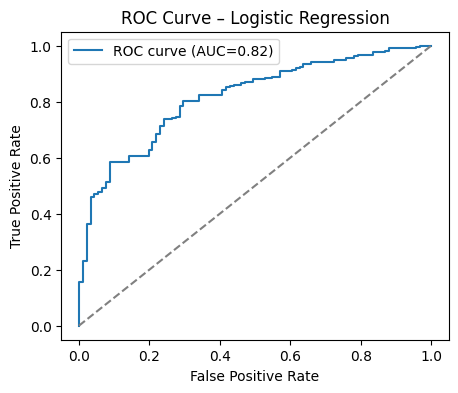

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import pandas as pd


# --- Fit Logistic Regression ---
log_reg = LogisticRegression(penalty=None)
log_reg.fit(X_train, y_train)

# --- Predictions ---
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

# --- Evaluation metrics ---
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Accuracy: {acc:.3f}")
print(f"AUC: {auc:.3f}")
print("Confusion Matrix:")
print(cm)

# --- Coefficients (top 10 by magnitude) ---
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\nTop 10 coefficients by magnitude:")
print(coef_df.head(10))

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC={auc:.2f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.show()

# --- Comments ---
# Test accuracy (0.757) indicates decent classification performance on unseen data.
# AUC = 0.815 suggests the model separates "good" vs "bad" credit reasonably well.
# The confusion matrix shows the model predicts most "good" cases correctly (186/209),
# though it misclassifies some "bad" loans as "good" (50 many).
# Key positive coefficients (e.g. 'checking_status_no checking', 'critical/other credit')
# imply higher odds of being a "good" borrower.
# Negative coefficients (e.g. 'purpose_education', 'foreign_worker_yes') reduce the chance of "good" credit.
# Overall, logistic regression provides interpretable results and solid discrimination power.



### Exercise 4.4: Regularized Logistic Regression (Lasso & Ridge)

* Fit Lasso (L1) and Ridge (L2) logistic regression models using LogisticRegressionCV with solver='liblinear' and StandardScaler in a pipeline.

* Compare performance (Accuracy, AUC, and Confusion Matrix) for both models.

* Identify which features are most strongly shrunk toward zero in Lasso.


In [438]:
# Features
y_4_1= df_4_1["class"].map({"good":1,"bad":0})
X_4_1 =df_4_1_one_hot_encoding
# Simple Train/Test Split (80% / 20%)

X_train_4_1, X_test_4_1, y_train_4_1, y_test_4_1 = train_test_split(
    X_4_1, y_4_1,
    test_size=0.30,
    random_state=42,  # sets seed for reproducibility
    shuffle=True      # set to False for time series data
)

#=========================================
# LASSO
#=========================================
las_log_pipe_4 = Pipeline([(
    'scaler', StandardScaler()),
    ('las_log', LogisticRegressionCV(cv=5,solver="liblinear",penalty="l1"),
     )])

# Fitting model

las_log_pipe_4.fit(X_train_4_1,y_train_4_1)

# Predicting and calc prob of the model 

y_pred_4_1=las_log_pipe_4.predict(X_test_4_1)

y_prob_4_1 = las_log_pipe_4.predict_proba(X_test_4_1)[:, 1] # it returns the probability for the 1 cases. can also be changed to 0


#=========================================
# RIDGE
#=========================================
log_ridg_pipe_4 = Pipeline([(
    'scaler', StandardScaler()),
    ('log_ridg', LogisticRegressionCV(cv=5,solver="liblinear",penalty="l2"),
     )])

# Fitting model

log_ridg_pipe_4.fit(X_train_4_1,y_train_4_1)

# Predicting and calc prob of the model 

y_pred_ridg=log_ridg_pipe_4.predict(X_test_4_1)

y_prob_ridg = log_ridg_pipe_4.predict_proba(X_test_4_1)[:, 1] # it returns the probability for the 1 cases. can also be changed to 0


#=========================================
#  Evaluation LASSO
#=========================================

# Confusion matrix 
tn_las,fp_las,fn_las,tp_las = confusion_matrix(y_test_4_1, y_pred_4_1).ravel() # ravel assignes the values to the variables. 

# Print confusion matrix
print("LASSO Confusion Matrix:")
print(f"[[TN={tn_las}, FP={fp_las}]")
print(f" [FN={fn_las}, TP={tp_las}]]")

print("Lasso Test accuracy:", round(accuracy_score(y_test_4_1, y_pred_4_1),3))

#AUC
fpr_las,tpr_las,threshold = roc_curve(y_test_4_1,y_prob_4_1)

roc_auc_las=auc(fpr_las,tpr_las)
print("LASSO AUC:",round(roc_auc_las,4))

#=========================================
#  Evaluation RIDGE
#=========================================

# Confusion matrix 
tn_ridg,fp_ridg,fn_ridg,tp_ridg = confusion_matrix(y_test_4_1, y_pred_ridg).ravel() # ravel assignes the values to the variables. 

# Print confusion matrix
print("\nRIDGE Confusion Matrix:")
print(f"[[TN={tn_ridg}, FP={fp_ridg}]")
print(f" [FN={fn_ridg}, TP={tp_ridg}]]")

print("RIDGE Test accuracy:", round(accuracy_score(y_test_4_1, y_pred_ridg),3))

#AUC
fpr_ridg,tpr_ridg,threshold = roc_curve(y_test_4_1,y_prob_ridg)

roc_auc_ridg=auc(fpr_ridg,tpr_ridg)
print("RIDGE AUC:",round(roc_auc_ridg,4))

#=========================================
#  Getting the coefficient
#=========================================
# Lasso
coef_log_las = las_log_pipe_4.named_steps['las_log'].coef_

#Ridge
coef_log_ridg = log_ridg_pipe_4.named_steps['log_ridg'].coef_


coef_comparison_las = pd.DataFrame({
    'Feature': X_4_1.columns,
    'Log_las_Coef': coef_log_las.ravel(),  #.ravel() converts it into a 1 dimension
    "Log_las_ridg": coef_log_ridg.ravel()

})
print(f"\n\nCoefficient for Lasso log regression:\n",coef_comparison_las.head(8))

# Largest impact 
print("\n\nCoefficients with largest impact:\n",
       coef_comparison_las.sort_values(by="Log_las_Coef", 
        key=abs, 
        ascending=True).head(20))







LASSO Confusion Matrix:
[[TN=45, FP=46]
 [FN=21, TP=188]]
Lasso Test accuracy: 0.777
LASSO AUC: 0.8166

RIDGE Confusion Matrix:
[[TN=55, FP=36]
 [FN=27, TP=182]]
RIDGE Test accuracy: 0.79
RIDGE AUC: 0.8107


Coefficient for Lasso log regression:
                   Feature  Log_las_Coef  Log_las_ridg
0                duration     -0.226937     -0.133243
1           credit_amount     -0.290052     -0.104753
2  installment_commitment     -0.309868     -0.085414
3         residence_since      0.000000     -0.005347
4                     age      0.271339      0.102509
5        existing_credits     -0.107470     -0.003128
6          num_dependents     -0.036153     -0.015736
7      one_hot_encoded_<0     -0.136016     -0.139092


Coefficients with largest impact:
                                     Feature  Log_las_Coef  Log_las_ridg
19                    one_hot_encoded_other      0.000000     -0.019654
45                  one_hot_encoded_skilled      0.000000      0.002052
44       one_h

### Solution

In [35]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np

# --- Lasso (L1) Logistic Regression ---
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LogisticRegressionCV(penalty='l1', solver='liblinear'))
])
lasso_pipe.fit(X_train, y_train)
y_pred_lasso = lasso_pipe.predict(X_test)
y_prob_lasso = lasso_pipe.predict_proba(X_test)[:, 1]
acc_lasso = accuracy_score(y_test, y_pred_lasso)
auc_lasso = roc_auc_score(y_test, y_prob_lasso)
cm_lasso = confusion_matrix(y_test, y_pred_lasso)

# --- Ridge (L2) Logistic Regression ---
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', LogisticRegressionCV(penalty='l2', solver='liblinear'))
])
ridge_pipe.fit(X_train, y_train)
y_pred_ridge = ridge_pipe.predict(X_test)
y_prob_ridge = ridge_pipe.predict_proba(X_test)[:, 1]
acc_ridge = accuracy_score(y_test, y_pred_ridge)
auc_ridge = roc_auc_score(y_test, y_prob_ridge)
cm_ridge = confusion_matrix(y_test, y_pred_ridge)

# --- Compare Coefficients ---
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Lasso_Coef': lasso_pipe.named_steps['lasso'].coef_.flatten(),
    'Ridge_Coef': ridge_pipe.named_steps['ridge'].coef_.flatten()
})
coef_df['Lasso_Abs'] = coef_df['Lasso_Coef'].abs()
coef_df['Ridge_Abs'] = coef_df['Ridge_Coef'].abs()
coef_df = coef_df.sort_values(by='Lasso_Abs', ascending=False)

print(f"Lasso Logistic Test Accuracy: {acc_lasso:.3f}, AUC: {auc_lasso:.3f}")
print(cm_lasso, "\n")
print(f"Ridge Logistic Test Accuracy: {acc_ridge:.3f}, AUC: {auc_ridge:.3f}")
print(cm_ridge)
print("\nTop 10 Lasso Coefficients:")
print(coef_df.head(10))

# --- Comments
# 1. Overall performance:
#    - Lasso logistic regression: Test Accuracy = 0.777, AUC = 0.817
#    - Ridge logistic regression: Test Accuracy = 0.790, AUC = 0.811
#    - Mild regularization (Ridge) slightly improves accuracy and stabilizes predictions.
# 2. Confusion matrices:
#    - Both models perform well on "good" credits, some misclassification on "bad" credits.
#    - Ridge improves balance between false positives and false negatives.
# 3. Coefficient comparison:
#    - Lasso shrinks some coefficients to zero, performing variable selection.
#    - Ridge shrinks all coefficients but keeps them non-zero; magnitudes are smaller.
# 4. Interpretation:
#    - Strongest predictors are checking status and credit history — aligns with domain knowledge.
#    - Lasso is sparser (more interpretable), Ridge is more stable.




Lasso Logistic Test Accuracy: 0.777, AUC: 0.817
[[ 45  46]
 [ 21 188]] 

Ridge Logistic Test Accuracy: 0.790, AUC: 0.811
[[ 55  36]
 [ 27 182]]

Top 10 Lasso Coefficients:
                                          Feature  Lasso_Coef  Ridge_Coef  \
9                     checking_status_no checking    0.554356    0.207148   
10  credit_history_critical/other existing credit    0.399801    0.133493   
2                          installment_commitment   -0.309821   -0.085414   
14                                purpose_new car   -0.300193   -0.111903   
1                                   credit_amount   -0.289994   -0.104753   
4                                             age    0.271351    0.102509   
0                                        duration   -0.226971   -0.133243   
15                               purpose_used car    0.210285    0.091853   
47                             foreign_worker_yes   -0.201335   -0.073118   
33                    personal_status_male single    0.185